# Meta-source CORAL training + full label-blind online evaluation

This notebook trains the Utah adapter on `New_Gesture_Trial_Dataset_Labeled (2).pt` while aligning its 16-channel output features to the official Meta HDF5 source domain with CORAL. The Meta backbone remains frozen. After validation-based checkpoint selection, the notebook freezes and saves the complete model, then runs the full blind detector/classifier replay on the older 53-trial `Gesture_Trial_Dataset_Labeled.pt`.

The 53-trial labels are used only after burst detection, window placement, active-bin selection, and gesture prediction are complete.


In [7]:
# ============================================================
# CELL 1 — CONFIGURATION + FROZEN META MODEL + 2 kHz ADAPTER
# ============================================================

from pathlib import Path
import sys
import random
import copy
import hashlib

import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

try:
    from scipy.signal import butter, sosfiltfilt, resample_poly
except ImportError as exc:
    raise ImportError(
        "This notebook requires scipy for anti-aliased resampling and "
        "40 Hz high-pass filtering. Install it with: pip install scipy"
    ) from exc

try:
    from torch.nn.utils.parametrizations import weight_norm
except ImportError:
    from torch.nn.utils import weight_norm


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

REPO_ROOT = Path(r"C:\Users\Micah\utah-neuro\generic_neuromotor_interface")
MODEL_DIR = REPO_ROOT / "emg_models" / "discrete_gestures"
CKPT_PATH = MODEL_DIR / "model_checkpoint.ckpt"

BASE_DIR = REPO_ROOT
DATA_PATH = BASE_DIR / "New_Gesture_Trial_Dataset_Labeled (2).pt"
META_SOURCE_DIR = BASE_DIR / "emg_data"

DA_EXPERIMENT_DIR = Path(r"C:\Users\Micah\utah-neuro\MATLAB_Jupyter\03_online_domain_adaptation\meta_coral_experiment")
DA_EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from generic_neuromotor_interface.networks import DiscreteGesturesArchitecture


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 0

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True


# ------------------------------------------------------------
# Data/model timing and output semantics
# ------------------------------------------------------------

YOUR_CHANNELS = 32
META_CHANNELS = 16

YOUR_SAMPLING_RATE = 30_000
META_SAMPLING_RATE = 2_000

RAW_INPUT_SAMPLES = 30_000       # one second at 30 kHz
META_INPUT_SAMPLES = 2_000       # one second at 2 kHz
UTAH_TO_META_DOWNSAMPLE = YOUR_SAMPLING_RATE // META_SAMPLING_RATE

if YOUR_SAMPLING_RATE % META_SAMPLING_RATE != 0:
    raise ValueError("Utah-to-Meta sampling-rate ratio must be an integer.")

NUM_META_CLASSES = 9
AO_KEPT_CLASSES = 5

AO_CLASS_NAMES = [
    "thumb left",
    "thumb right",
    "thumb up",
    "thumb down",
    "thumb press",
]

# Meta output order:
# 0 index press
# 1 index release
# 2 middle press
# 3 middle release
# 4 thumb tap
# 5 thumb swipe left
# 6 thumb swipe right
# 7 thumb swipe up
# 8 thumb swipe down
UTAH_TO_META_OUTPUTS = [5, 6, 7, 8, 4]

if len(UTAH_TO_META_OUTPUTS) != AO_KEPT_CLASSES:
    raise ValueError("UTAH_TO_META_OUTPUTS must contain five indices.")

if len(set(UTAH_TO_META_OUTPUTS)) != AO_KEPT_CLASSES:
    raise ValueError("UTAH_TO_META_OUTPUTS contains duplicate indices.")

if not all(0 <= index < NUM_META_CLASSES for index in UTAH_TO_META_OUTPUTS):
    raise ValueError("UTAH_TO_META_OUTPUTS contains an invalid Meta output index.")


# ------------------------------------------------------------
# Training configuration
# ------------------------------------------------------------

BATCH_SIZE = 16
AO_EPOCHS = 200

AO_LR = 0.01
AO_WEIGHT_DECAY = 1e-3
AO_GRAD_CLIP_NORM = 1.0

AO_WARMUP_EPOCHS = 5
AO_DECAY_EPOCH = 26
AO_DECAY_FACTOR = 0.5

# ------------------------------------------------------------
# CORAL domain-adaptation experiment toggle
# ------------------------------------------------------------
# True:
#   total loss = mapped task BCE + lambda * EMG-feature CORAL
# False:
#   task-only baseline; Meta source loading and CORAL are skipped
USE_CORAL_DA = True

# Used only when USE_CORAL_DA is True.
EMG_FEATURE_CORAL_LAMBDA = 1
MAX_CORAL_SAMPLES = 4096

EMG_FEATURE_WINDOW_MS = 100.0
EMG_FEATURE_WINDOW_SAMPLES = int(
    round(META_SAMPLING_RATE * EMG_FEATURE_WINDOW_MS / 1000.0)
)
EMG_FEATURE_LOG1P_AMPLITUDE = True
EMG_FEATURE_STD_EPS = 1e-8

# Refuse to start training when weighted CORAL is catastrophically larger
# than task loss. Change only after inspecting Cell 5.
MAX_PREFLIGHT_WEIGHTED_CORAL_TO_TASK = 20.0
ALLOW_UNSAFE_CORAL_START = False

# The saved Utah dataset is expected to already contain the previously chosen
# 100 ms forward label shift. This notebook does NOT shift labels a second time.
UTAH_LABELS_ALREADY_SHIFTED_100_MS = True

EXPECTED_SPLIT_SIZES = {
    "train": 80,
    "val": 10,
    "test": 10,
}


# ------------------------------------------------------------
# Preprocessing configuration
# ------------------------------------------------------------

HIGH_PASS_HZ = 40.0
HIGH_PASS_ORDER = 4

# The official released Meta HDF5 is already 2 kHz and high-pass filtered at
# 40 Hz. Therefore both are False by default.
APPLY_META_SOURCE_HIGHPASS = False
APPLY_META_SOURCE_SCALE = False

# Diagnostic candidate only. The Nature paper reports 2.46 microvolts RMS as
# the device noise level; it is not documented by the official repository as
# a multiplier for the released HDF5 samples.
META_SOURCE_SCALE_CANDIDATE = 2.46e-6

# Utah hardware units are dataset-specific. Do not apply the Meta candidate
# factor to Utah.
UTAH_INPUT_SCALE = 1.0

# Official DiscreteGesturesArchitecture returns logits, not probabilities.
META_OUTPUT_IS_PROBABILITY = False


# ------------------------------------------------------------
# Adapter configuration
# ------------------------------------------------------------

ADAPTER_HIDDEN_CHANNELS = 48
ADAPTER_GROUPS = 8
ADAPTER_KERNEL_SIZE = 5
INITIAL_RESIDUAL_SCALE = 0.10
INITIAL_OUTPUT_GAIN = 0.25

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ------------------------------------------------------------
# Signal preprocessing helpers
# ------------------------------------------------------------

def make_highpass_sos(sample_rate, cutoff_hz=40.0, order=4):
    if not 0 < cutoff_hz < sample_rate / 2:
        raise ValueError(
            f"High-pass cutoff {cutoff_hz} Hz is invalid for "
            f"sample rate {sample_rate} Hz."
        )

    return butter(
        order,
        cutoff_hz,
        btype="highpass",
        fs=sample_rate,
        output="sos",
    )


META_HIGHPASS_SOS = make_highpass_sos(
    META_SAMPLING_RATE,
    HIGH_PASS_HZ,
    HIGH_PASS_ORDER,
)


def highpass_numpy_channels_time(x_ct, sos=META_HIGHPASS_SOS):
    """
    Apply a zero-phase 40 Hz high-pass to [channels,time].
    """
    x = np.asarray(x_ct, dtype=np.float32)

    if x.ndim != 2:
        raise ValueError(f"Expected [channels,time], got {x.shape}")

    if x.shape[1] < 32:
        raise ValueError(
            f"Signal is too short for stable high-pass filtering: {x.shape}"
        )

    return sosfiltfilt(sos, x, axis=1).astype(np.float32, copy=False)


def resample_utah_30k_to_2k(x_ct):
    """
    Anti-aliased rational resampling:
        [32,30000] at 30 kHz -> [32,2000] at 2 kHz.
    """
    x = np.asarray(x_ct, dtype=np.float32)

    if x.ndim != 2:
        raise ValueError(f"Expected [channels,time], got {x.shape}")

    if x.shape[0] != YOUR_CHANNELS:
        raise ValueError(
            f"Expected {YOUR_CHANNELS} Utah channels, got {x.shape}"
        )

    if x.shape[1] != RAW_INPUT_SAMPLES:
        raise ValueError(
            f"Expected exactly {RAW_INPUT_SAMPLES} Utah samples, got {x.shape}"
        )

    y = resample_poly(
        x,
        up=1,
        down=UTAH_TO_META_DOWNSAMPLE,
        axis=1,
    )

    if y.shape != (YOUR_CHANNELS, META_INPUT_SAMPLES):
        raise RuntimeError(
            "Unexpected anti-aliased resampling shape: "
            f"expected {(YOUR_CHANNELS, META_INPUT_SAMPLES)}, got {y.shape}"
        )

    return y.astype(np.float32, copy=False)


def preprocess_utah_trial(x_ct):
    """
    Utah:
        30 kHz -> anti-aliased 2 kHz -> 40 Hz high-pass -> optional Utah scale.
    """
    y = resample_utah_30k_to_2k(x_ct)
    y = highpass_numpy_channels_time(y)
    y = y * float(UTAH_INPUT_SCALE)
    return y.astype(np.float32, copy=False)


def preprocess_meta_source(
    x_ct,
    apply_scale=APPLY_META_SOURCE_SCALE,
    apply_highpass=APPLY_META_SOURCE_HIGHPASS,
):
    """
    Meta released HDF5:
        already 2 kHz and already 40 Hz high-pass filtered.

    No external Reinhard compression is applied. The frozen Meta model applies
    64*x/(32+|x|) internally.
    """
    y = np.asarray(x_ct, dtype=np.float32)

    if y.shape != (META_CHANNELS, META_INPUT_SAMPLES):
        raise ValueError(
            f"Expected Meta source {(META_CHANNELS, META_INPUT_SAMPLES)}, "
            f"got {y.shape}"
        )

    if apply_scale:
        y = y * float(META_SOURCE_SCALE_CANDIDATE)

    if apply_highpass:
        y = highpass_numpy_channels_time(y)

    return y.astype(np.float32, copy=False)


# ------------------------------------------------------------
# Load and freeze the official Meta model
# ------------------------------------------------------------

if not CKPT_PATH.exists():
    raise FileNotFoundError(f"Could not find Meta checkpoint:\n{CKPT_PATH}")

meta_model = DiscreteGesturesArchitecture(output_channels=NUM_META_CLASSES)

ckpt = torch.load(CKPT_PATH, map_location="cpu", weights_only=False)

if "state_dict" not in ckpt:
    raise KeyError("Checkpoint is missing 'state_dict'.")

state = ckpt["state_dict"]

network_state = {
    key.replace("network.", "", 1): value
    for key, value in state.items()
    if key.startswith("network.")
}

if not network_state:
    network_state = state

meta_model.load_state_dict(network_state, strict=True)

for parameter in meta_model.parameters():
    parameter.requires_grad = False

meta_model.eval()

# Verify the imported official architecture.
if not hasattr(meta_model, "compression"):
    raise RuntimeError("Meta model has no compression module.")

compression_range = float(getattr(meta_model.compression, "range", np.nan))
compression_midpoint = float(getattr(meta_model.compression, "midpoint", np.nan))

if not np.isclose(compression_range, 64.0):
    raise RuntimeError(
        f"Expected Meta compression range=64, got {compression_range}"
    )

if not np.isclose(compression_midpoint, 32.0):
    raise RuntimeError(
        f"Expected Meta compression midpoint=32, got {compression_midpoint}"
    )

META_LEFT_CONTEXT = int(meta_model.left_context)
META_OUTPUT_STRIDE = int(meta_model.stride)
EXPECTED_META_OUTPUT_SAMPLES = len(
    range(META_LEFT_CONTEXT, META_INPUT_SAMPLES, META_OUTPUT_STRIDE)
)


# ------------------------------------------------------------
# Regularized 32-channel -> 16-channel TCN adapter
# ------------------------------------------------------------

def make_group_norm(num_channels, requested_groups=8):
    groups = min(requested_groups, num_channels)

    while groups > 1 and num_channels % groups != 0:
        groups -= 1

    return nn.GroupNorm(groups, num_channels)


def make_wn_conv1d(
    in_channels,
    out_channels,
    kernel_size,
    padding=0,
    dilation=1,
    groups=1,
    bias=True,
):
    layer = nn.Conv1d(
        in_channels,
        out_channels,
        kernel_size=kernel_size,
        padding=padding,
        dilation=dilation,
        groups=groups,
        bias=bias,
    )
    return weight_norm(layer)


class DepthwiseSeparableTemporalConv(nn.Module):
    def __init__(
        self,
        channels,
        kernel_size=5,
        dilation=1,
        norm_groups=8,
    ):
        super().__init__()

        padding = dilation * (kernel_size - 1) // 2

        self.depthwise = make_wn_conv1d(
            channels,
            channels,
            kernel_size=kernel_size,
            padding=padding,
            dilation=dilation,
            groups=channels,
            bias=False,
        )

        self.pointwise = make_wn_conv1d(
            channels,
            channels,
            kernel_size=1,
            bias=False,
        )

        self.norm = make_group_norm(channels, norm_groups)
        self.activation = nn.SiLU()

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        x = self.norm(x)
        return self.activation(x)


class RegularizedTCNBlock(nn.Module):
    def __init__(
        self,
        channels,
        kernel_size=5,
        dilation=1,
        norm_groups=8,
        initial_residual_scale=0.10,
    ):
        super().__init__()

        self.temporal_1 = DepthwiseSeparableTemporalConv(
            channels,
            kernel_size,
            dilation,
            norm_groups,
        )
        self.temporal_2 = DepthwiseSeparableTemporalConv(
            channels,
            kernel_size,
            dilation,
            norm_groups,
        )

        self.residual_scale = nn.Parameter(
            torch.tensor(float(initial_residual_scale))
        )

    def forward(self, x):
        residual = x
        out = self.temporal_1(x)
        out = self.temporal_2(out)
        return residual + self.residual_scale * out


class AdapterToMetaInput(nn.Module):
    """
    [B,32,2000] -> [B,16,2000].

    The adapter changes the channel representation without changing physical
    duration or sampling rate.
    """
    def __init__(
        self,
        input_channels=32,
        output_channels=16,
        hidden_channels=48,
    ):
        super().__init__()

        self.input_projection = nn.Sequential(
            make_wn_conv1d(
                input_channels,
                hidden_channels,
                kernel_size=1,
                bias=False,
            ),
            make_group_norm(hidden_channels, ADAPTER_GROUPS),
            nn.SiLU(),
        )

        self.temporal_stack = nn.Sequential(
            RegularizedTCNBlock(
                hidden_channels,
                ADAPTER_KERNEL_SIZE,
                dilation=1,
                norm_groups=ADAPTER_GROUPS,
                initial_residual_scale=INITIAL_RESIDUAL_SCALE,
            ),
            RegularizedTCNBlock(
                hidden_channels,
                ADAPTER_KERNEL_SIZE,
                dilation=2,
                norm_groups=ADAPTER_GROUPS,
                initial_residual_scale=INITIAL_RESIDUAL_SCALE,
            ),
            RegularizedTCNBlock(
                hidden_channels,
                ADAPTER_KERNEL_SIZE,
                dilation=4,
                norm_groups=ADAPTER_GROUPS,
                initial_residual_scale=INITIAL_RESIDUAL_SCALE,
            ),
            RegularizedTCNBlock(
                hidden_channels,
                ADAPTER_KERNEL_SIZE,
                dilation=8,
                norm_groups=ADAPTER_GROUPS,
                initial_residual_scale=INITIAL_RESIDUAL_SCALE,
            ),
        )

        self.output_projection = make_wn_conv1d(
            hidden_channels,
            output_channels,
            kernel_size=1,
            bias=True,
        )

        self.output_gain = nn.Parameter(
            torch.tensor(float(INITIAL_OUTPUT_GAIN))
        )

    def forward(self, x):
        if x.ndim != 3:
            raise ValueError(f"Expected [B,32,T], got {tuple(x.shape)}")

        if x.shape[1] != YOUR_CHANNELS:
            raise ValueError(
                f"Expected {YOUR_CHANNELS} Utah channels, got {tuple(x.shape)}"
            )

        if x.shape[-1] != META_INPUT_SAMPLES:
            raise ValueError(
                f"Expected one second at 2 kHz (T={META_INPUT_SAMPLES}), "
                f"got T={x.shape[-1]}"
            )

        x = self.input_projection(x)
        x = self.temporal_stack(x)
        x = self.output_projection(x)
        return self.output_gain * x


class FrozenMetaWithAdapter(nn.Module):
    def __init__(self, frozen_meta_model):
        super().__init__()

        self.adapter = AdapterToMetaInput(
            input_channels=YOUR_CHANNELS,
            output_channels=META_CHANNELS,
            hidden_channels=ADAPTER_HIDDEN_CHANNELS,
        )

        self.meta_model = frozen_meta_model

        for parameter in self.meta_model.parameters():
            parameter.requires_grad = False

        self.meta_model.eval()

    def train(self, mode=True):
        super().train(mode)
        self.meta_model.eval()
        return self

    def forward_with_adapter(self, x):
        adapter_output = self.adapter(x)
        raw_meta_output = self.meta_model(adapter_output)
        return raw_meta_output, adapter_output

    def forward(self, x):
        raw_meta_output, _ = self.forward_with_adapter(x)
        return raw_meta_output


def module_numeric_signature(module):
    """
    Lightweight frozen-model mutation check.
    """
    total_sum = 0.0
    total_sq_sum = 0.0
    total_count = 0

    with torch.no_grad():
        for tensor in module.state_dict().values():
            value = tensor.detach().double().cpu()
            total_sum += float(value.sum().item())
            total_sq_sum += float(value.square().sum().item())
            total_count += value.numel()

    return (total_count, total_sum, total_sq_sum)


model = FrozenMetaWithAdapter(meta_model).to(DEVICE)
initial_adapter_state = copy.deepcopy(model.adapter.state_dict())
initial_meta_signature = module_numeric_signature(model.meta_model)

total_params = sum(parameter.numel() for parameter in model.parameters())
trainable_params = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

if any(parameter.requires_grad for parameter in model.meta_model.parameters()):
    raise RuntimeError("The Meta backbone is not fully frozen.")

print("Using device:", DEVICE)
print("Physical timing:")
print(
    f"  Utah raw: {RAW_INPUT_SAMPLES} samples @ "
    f"{YOUR_SAMPLING_RATE} Hz = 1.000 s"
)
print(
    f"  Meta input: {META_INPUT_SAMPLES} samples @ "
    f"{META_SAMPLING_RATE} Hz = 1.000 s"
)
print(
    f"  Meta output: {EXPECTED_META_OUTPUT_SAMPLES} bins using "
    f"left_context={META_LEFT_CONTEXT}, stride={META_OUTPUT_STRIDE}"
)
print("Output mapping:", UTAH_TO_META_OUTPUTS)
print("Meta source scale applied:", APPLY_META_SOURCE_SCALE)
print("Extra Meta source high-pass applied:", APPLY_META_SOURCE_HIGHPASS)
print(
    "Meta internal compression:",
    f"{compression_range:g}*x/({compression_midpoint:g}+|x|)",
)
print("Total parameters:", f"{total_params:,}")
print("Trainable adapter parameters:", f"{trainable_params:,}")
print("Frozen parameters:", f"{total_params - trainable_params:,}")


Using device: cpu
Physical timing:
  Utah raw: 30000 samples @ 30000 Hz = 1.000 s
  Meta input: 2000 samples @ 2000 Hz = 1.000 s
  Meta output: 198 bins using left_context=20, stride=10
Output mapping: [5, 6, 7, 8, 4]
Meta source scale applied: False
Extra Meta source high-pass applied: False
Meta internal compression: 64*x/(32+|x|)
Total parameters: 6,507,326
Trainable adapter parameters: 24,373
Frozen parameters: 6,482,953


In [8]:
# ============================================================
# CELL 2 — LOAD, CENTER-CROP, AND VALIDATE FIXED UTAH SPLITS
#
# IMPORTANT:
# The saved Utah entries are variable-length gesture-to-next-gesture
# segments. They are NOT already one-second trials.
#
# This cell:
#   1. finds the final active-valid label interval in trial-local coordinates,
#   2. extracts one 30,000-sample window centered on that interval,
#   3. applies the identical crop/pad to EMG, labels, and valid mask,
#   4. downsamples the one-second window exactly from 30 kHz to 2 kHz,
#   5. drops genuinely unusable TRAIN trials only,
#   6. hard-stops if any validation/test trial is unusable.
# ============================================================

from collections import defaultdict

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find labeled dataset:\n{DATA_PATH}"
    )


# ------------------------------------------------------------
# Orientation helpers
# ------------------------------------------------------------

def force_emg_time_channels(x):
    """Return Utah EMG as [time, 32]."""
    x = torch.as_tensor(x).float()

    if x.ndim != 2:
        raise ValueError(f"Expected 2D EMG, got {tuple(x.shape)}")

    if x.shape[1] == YOUR_CHANNELS:
        return x.contiguous()

    if x.shape[0] == YOUR_CHANNELS:
        return x.transpose(0, 1).contiguous()

    raise ValueError(
        f"Could not identify {YOUR_CHANNELS}-channel EMG orientation: "
        f"{tuple(x.shape)}"
    )


def force_labels_time_classes(x, expected_time):
    """Return labels as [time, classes]."""
    x = torch.as_tensor(x).float()

    if x.ndim != 2:
        raise ValueError(f"Expected 2D labels, got {tuple(x.shape)}")

    candidates = []

    if x.shape[0] == expected_time and x.shape[1] >= AO_KEPT_CLASSES:
        candidates.append(x.contiguous())

    if x.shape[1] == expected_time and x.shape[0] >= AO_KEPT_CLASSES:
        candidates.append(x.transpose(0, 1).contiguous())

    if len(candidates) == 1:
        return candidates[0]

    if len(candidates) > 1:
        raise ValueError(
            f"Ambiguous label orientation for shape {tuple(x.shape)} "
            f"and expected_time={expected_time}."
        )

    # Fallback when EMG and labels differ slightly in length.
    if x.shape[0] > x.shape[1] and x.shape[1] >= AO_KEPT_CLASSES:
        return x.contiguous()

    if x.shape[1] > x.shape[0] and x.shape[0] >= AO_KEPT_CLASSES:
        return x.transpose(0, 1).contiguous()

    raise ValueError(
        f"Could not identify label orientation: {tuple(x.shape)}"
    )


# ------------------------------------------------------------
# Trial-local active interval and one-second extraction
# ------------------------------------------------------------

def get_common_trial_arrays(trial):
    """
    Return aligned trial-local arrays:
        emg_tc:    [T,32]
        labels_tc: [T,C]
        valid_t:   [T]
    """
    if "ns5_vector" not in trial:
        raise KeyError("Trial is missing 'ns5_vector'.")

    if "trainKin" not in trial:
        raise KeyError("Trial is missing 'trainKin'.")

    emg_tc = force_emg_time_channels(trial["ns5_vector"])
    labels_tc = force_labels_time_classes(
        trial["trainKin"],
        expected_time=emg_tc.shape[0],
    )

    if "valid_mask" in trial:
        valid_t = torch.as_tensor(
            trial["valid_mask"]
        ).float().reshape(-1)
    else:
        valid_t = torch.ones(
            emg_tc.shape[0],
            dtype=torch.float32,
        )

    common_length = min(
        emg_tc.shape[0],
        labels_tc.shape[0],
        valid_t.shape[0],
    )

    if common_length <= 0:
        raise ValueError("Trial has no common EMG/label/mask samples.")

    return (
        emg_tc[:common_length].contiguous(),
        labels_tc[:common_length].contiguous(),
        valid_t[:common_length].contiguous(),
    )


def find_active_valid_interval(labels_tc, valid_t):
    """
    Find the first and last trial-local samples where:
        any Utah gesture label is active
        AND
        valid_mask == 1

    Returns None when the final saved trial has no usable active label.
    """
    active_t = (
        labels_tc[:, :AO_KEPT_CLASSES].amax(dim=1) > 0.5
    )
    valid_bool = valid_t > 0.5
    active_valid_t = active_t & valid_bool

    indices = torch.nonzero(
        active_valid_t,
        as_tuple=False,
    ).reshape(-1)

    if indices.numel() == 0:
        return None

    start = int(indices[0].item())
    end_exclusive = int(indices[-1].item()) + 1

    return start, end_exclusive


def extract_centered_time_window(
    x,
    center_index,
    target_samples,
    pad_value=0.0,
):
    """
    Extract one time-first window centered on `center_index`.

    If the full trial is at least target_samples long, the window is shifted
    at the boundaries so it contains only real samples.

    If the full trial is shorter than target_samples, it is padded while
    keeping the active interval center aligned to the middle of the output.

    Returns:
        output
        source_start
        source_end
        left_pad
        right_pad
    """
    if x.ndim < 1:
        raise ValueError("Input must have a time dimension.")

    total_samples = int(x.shape[0])
    target_samples = int(target_samples)
    center_index = int(center_index)

    if total_samples <= 0:
        raise ValueError("Cannot crop an empty trial.")

    if not 0 <= center_index < total_samples:
        raise ValueError(
            f"center_index={center_index} is outside trial length "
            f"{total_samples}."
        )

    if total_samples >= target_samples:
        source_start = center_index - target_samples // 2
        source_start = max(0, source_start)
        source_start = min(source_start, total_samples - target_samples)
        source_end = source_start + target_samples

        return (
            x[source_start:source_end].contiguous(),
            source_start,
            source_end,
            0,
            0,
        )

    # Short trial: preserve active-center alignment with explicit padding.
    desired_start = center_index - target_samples // 2
    desired_end = desired_start + target_samples

    source_start = max(0, desired_start)
    source_end = min(total_samples, desired_end)

    left_pad = source_start - desired_start
    copied = source_end - source_start
    right_pad = target_samples - left_pad - copied

    output_shape = (target_samples,) + tuple(x.shape[1:])
    output = torch.full(
        output_shape,
        float(pad_value),
        dtype=x.dtype,
    )

    destination_start = left_pad
    destination_end = destination_start + copied
    output[destination_start:destination_end] = x[source_start:source_end]

    return (
        output.contiguous(),
        source_start,
        source_end,
        left_pad,
        right_pad,
    )


def extract_one_second_active_centered_trial(trial):
    """
    Apply one identical trial-local crop/pad to EMG, labels, and valid mask.
    """
    emg_tc, labels_tc, valid_t = get_common_trial_arrays(trial)

    interval = find_active_valid_interval(labels_tc, valid_t)

    if interval is None:
        return None

    active_start, active_end = interval
    active_span = active_end - active_start

    if active_span > RAW_INPUT_SAMPLES:
        gesture = int(trial.get("gesture", -1))
        trial_num = int(trial.get("trial_num", -1))
        raise ValueError(
            f"G{gesture} trial {trial_num} has an active-valid interval "
            f"of {active_span} samples, longer than the one-second "
            f"window ({RAW_INPUT_SAMPLES})."
        )

    active_center = (active_start + active_end - 1) // 2

    emg_window, source_start, source_end, left_pad, right_pad = (
        extract_centered_time_window(
            emg_tc,
            center_index=active_center,
            target_samples=RAW_INPUT_SAMPLES,
            pad_value=0.0,
        )
    )

    labels_window, labels_source_start, labels_source_end, labels_left_pad, labels_right_pad = (
        extract_centered_time_window(
            labels_tc,
            center_index=active_center,
            target_samples=RAW_INPUT_SAMPLES,
            pad_value=0.0,
        )
    )

    valid_window, valid_source_start, valid_source_end, valid_left_pad, valid_right_pad = (
        extract_centered_time_window(
            valid_t,
            center_index=active_center,
            target_samples=RAW_INPUT_SAMPLES,
            pad_value=0.0,
        )
    )

    crop_metadata = {
        "original_length": int(emg_tc.shape[0]),
        "active_start": active_start,
        "active_end": active_end,
        "active_span": active_span,
        "active_center": active_center,
        "source_start": source_start,
        "source_end": source_end,
        "left_pad": left_pad,
        "right_pad": right_pad,
    }

    consistency_values = {
        (
            source_start,
            source_end,
            left_pad,
            right_pad,
        ),
        (
            labels_source_start,
            labels_source_end,
            labels_left_pad,
            labels_right_pad,
        ),
        (
            valid_source_start,
            valid_source_end,
            valid_left_pad,
            valid_right_pad,
        ),
    }

    if len(consistency_values) != 1:
        raise RuntimeError(
            "EMG, labels, and valid mask did not receive the same crop."
        )

    if emg_window.shape != (RAW_INPUT_SAMPLES, YOUR_CHANNELS):
        raise RuntimeError(
            f"Unexpected cropped EMG shape: {tuple(emg_window.shape)}"
        )

    if labels_window.shape[0] != RAW_INPUT_SAMPLES:
        raise RuntimeError(
            f"Unexpected cropped label shape: {tuple(labels_window.shape)}"
        )

    if valid_window.shape != (RAW_INPUT_SAMPLES,):
        raise RuntimeError(
            f"Unexpected cropped valid-mask shape: "
            f"{tuple(valid_window.shape)}"
        )

    return emg_window, labels_window, valid_window, crop_metadata


# ------------------------------------------------------------
# Exact 30 kHz -> 2 kHz label/mask reduction
# ------------------------------------------------------------

def downsample_binary_labels_30k_to_2k(labels_tc):
    """
    Exact 15:1 block max pooling.

    A positive label survives when any corresponding 30 kHz sample is positive.
    """
    if labels_tc.shape[0] != RAW_INPUT_SAMPLES:
        raise ValueError(
            f"Expected {RAW_INPUT_SAMPLES} label samples, got "
            f"{tuple(labels_tc.shape)}"
        )

    labels_ct = labels_tc.transpose(0, 1).unsqueeze(0)

    pooled = F.max_pool1d(
        labels_ct,
        kernel_size=UTAH_TO_META_DOWNSAMPLE,
        stride=UTAH_TO_META_DOWNSAMPLE,
    )

    pooled_tc = pooled.squeeze(0).transpose(0, 1).contiguous()

    if pooled_tc.shape[0] != META_INPUT_SAMPLES:
        raise RuntimeError(
            f"Label downsampling produced {pooled_tc.shape[0]} samples."
        )

    return pooled_tc


def downsample_valid_mask_30k_to_2k(valid_t):
    """
    Exact conservative 15:1 validity reduction.

    A 2 kHz sample is valid only when every contributing 30 kHz sample is valid.
    """
    if valid_t.shape[0] != RAW_INPUT_SAMPLES:
        raise ValueError(
            f"Expected {RAW_INPUT_SAMPLES} valid-mask samples, got "
            f"{tuple(valid_t.shape)}"
        )

    invalid = (1.0 - valid_t.clamp(0.0, 1.0)).reshape(1, 1, -1)

    pooled_invalid = F.max_pool1d(
        invalid,
        kernel_size=UTAH_TO_META_DOWNSAMPLE,
        stride=UTAH_TO_META_DOWNSAMPLE,
    )

    valid_2k = 1.0 - pooled_invalid.reshape(-1)

    if valid_2k.shape[0] != META_INPUT_SAMPLES:
        raise RuntimeError(
            f"Valid-mask downsampling produced {valid_2k.shape[0]} samples."
        )

    return valid_2k.float().contiguous()


# ------------------------------------------------------------
# Load and structurally validate saved splits
# ------------------------------------------------------------

saved = torch.load(
    DATA_PATH,
    map_location="cpu",
    weights_only=False,
)

for split_name in ["train", "val", "test"]:
    if split_name not in saved:
        raise KeyError(
            f"Dataset is missing fixed split '{split_name}'. "
            f"Available keys: {list(saved.keys())}"
        )


def split_gesture_counts(trials):
    counts = {
        class_index: 0
        for class_index in range(AO_KEPT_CLASSES)
    }

    for trial in trials:
        gesture = int(trial.get("gesture", -1))
        if gesture in counts:
            counts[gesture] += 1

    return counts


def split_trial_keys(trials):
    keys = set()

    for index, trial in enumerate(trials):
        gesture = int(trial.get("gesture", -1))
        trial_num = int(trial.get("trial_num", index))
        key = (gesture, trial_num)

        if key in keys:
            raise ValueError(
                f"Duplicate trial key within split: {key}"
            )

        keys.add(key)

    return keys


for split_name, expected_size in EXPECTED_SPLIT_SIZES.items():
    actual_size = len(saved[split_name])

    if actual_size != expected_size:
        raise ValueError(
            f"Expected {expected_size} {split_name} trials, "
            f"got {actual_size}."
        )

    counts = split_gesture_counts(saved[split_name])
    missing_classes = [
        class_index
        for class_index, count in counts.items()
        if count == 0
    ]

    if missing_classes:
        raise ValueError(
            f"{split_name} split is missing gesture classes: "
            f"{missing_classes}"
        )


train_keys = split_trial_keys(saved["train"])
val_keys = split_trial_keys(saved["val"])
test_keys = split_trial_keys(saved["test"])

if train_keys & val_keys:
    raise ValueError("Train and validation splits overlap.")

if train_keys & test_keys:
    raise ValueError("Train and test splits overlap.")

if val_keys & test_keys:
    raise ValueError("Validation and test splits overlap.")


# ------------------------------------------------------------
# Pre-loader audit
# ------------------------------------------------------------

true_no_active_trials = []
post_crop_failures = []
crop_summaries = defaultdict(list)
usable_trials = defaultdict(list)

for split_name in ["train", "val", "test"]:
    for index, trial in enumerate(saved[split_name]):
        gesture = int(trial.get("gesture", -1))
        trial_num = int(trial.get("trial_num", index))

        extracted = extract_one_second_active_centered_trial(trial)

        if extracted is None:
            emg_tc, labels_tc, valid_t = get_common_trial_arrays(trial)

            raw_active = (
                labels_tc[:, :AO_KEPT_CLASSES].amax(dim=1) > 0.5
            )
            raw_valid = valid_t > 0.5

            true_no_active_trials.append(
                {
                    "split": split_name,
                    "gesture": gesture,
                    "trial_num": trial_num,
                    "length": int(emg_tc.shape[0]),
                    "raw_active_samples": int(raw_active.sum().item()),
                    "raw_valid_samples": int(raw_valid.sum().item()),
                    "active_valid_overlap": int(
                        (raw_active & raw_valid).sum().item()
                    ),
                }
            )
            continue

        _, labels_window, valid_window, crop_metadata = extracted

        labels_2k_tc = downsample_binary_labels_30k_to_2k(
            labels_window[:, :AO_KEPT_CLASSES]
        )
        valid_2k = downsample_valid_mask_30k_to_2k(
            valid_window
        )

        active_valid_2k = (
            labels_2k_tc.amax(dim=1) > 0.5
        ) & (valid_2k > 0.5)

        crop_summaries[split_name].append(crop_metadata)

        if int(active_valid_2k.sum().item()) == 0:
            post_crop_failures.append(
                {
                    "split": split_name,
                    "gesture": gesture,
                    "trial_num": trial_num,
                    **crop_metadata,
                }
            )
            continue

        usable_trials[split_name].append(trial)


print("=" * 88)
print("ONE-SECOND ACTIVE-CENTERED CROP AUDIT")
print("=" * 88)

for split_name in ["train", "val", "test"]:
    summaries = crop_summaries[split_name]

    if summaries:
        active_spans = [
            item["active_span"]
            for item in summaries
        ]
        left_pads = [
            item["left_pad"]
            for item in summaries
        ]
        right_pads = [
            item["right_pad"]
            for item in summaries
        ]

        print(
            f"{split_name:>5}: "
            f"{len(summaries)} usable before final validation | "
            f"active span min/median/max = "
            f"{min(active_spans)}/"
            f"{int(torch.tensor(active_spans).float().median().item())}/"
            f"{max(active_spans)} | "
            f"padded trials = "
            f"{sum((l > 0 or r > 0) for l, r in zip(left_pads, right_pads))}"
        )
    else:
        print(f"{split_name:>5}: 0 usable before final validation")


if true_no_active_trials:
    print("\nGENUINELY UNUSABLE BEFORE CROPPING:")
    for item in true_no_active_trials:
        print(
            f"  {item['split']:>5} | "
            f"G{item['gesture']} trial {item['trial_num']} | "
            f"length={item['length']} | "
            f"active={item['raw_active_samples']} | "
            f"valid={item['raw_valid_samples']} | "
            f"active-valid={item['active_valid_overlap']}"
        )
else:
    print("\nNo genuinely unusable trials found before cropping.")


if post_crop_failures:
    print("\nFAILURES INTRODUCED BY CROP/DOWNSAMPLING:")
    for item in post_crop_failures:
        print(
            f"  {item['split']:>5} | "
            f"G{item['gesture']} trial {item['trial_num']} | "
            f"active span={item['active_span']} | "
            f"source=[{item['source_start']}:{item['source_end']}] | "
            f"pad=({item['left_pad']},{item['right_pad']})"
        )
else:
    print("\nNo usable trial lost its active label after centered cropping/downsampling.")


# Training trials without a meaningful active-valid burst are intentionally
# excluded. Validation and test trials are protected: losing even one is an
# evaluation failure and stops the notebook.
train_unusable = [
    item for item in true_no_active_trials
    if item["split"] == "train"
]
holdout_unusable = [
    item for item in true_no_active_trials
    if item["split"] in {"val", "test"}
]
holdout_post_crop_failures = [
    item for item in post_crop_failures
    if item["split"] in {"val", "test"}
]
train_post_crop_failures = [
    item for item in post_crop_failures
    if item["split"] == "train"
]

if holdout_unusable or holdout_post_crop_failures:
    raise RuntimeError(
        "\nA validation or test trial is unusable. Holdout trials must never be "
        "silently excluded; repair or replace the affected fixed holdout "
        "trial in the dataset-creation notebook."
    )

if train_post_crop_failures:
    raise RuntimeError(
        "\nAt least one otherwise usable training trial lost its label during "
        "cropping/downsampling. This indicates a loader bug and must not be "
        "silently excluded."
    )

filtered_train_trials = list(usable_trials["train"])
filtered_val_trials = list(usable_trials["val"])
filtered_test_trials = list(usable_trials["test"])

if len(filtered_val_trials) != EXPECTED_SPLIT_SIZES["val"]:
    raise RuntimeError(
        f"Validation must retain all {EXPECTED_SPLIT_SIZES['val']} fixed "
        f"trials, but {len(filtered_val_trials)} remain."
    )

if len(filtered_test_trials) != EXPECTED_SPLIT_SIZES["test"]:
    raise RuntimeError(
        f"Test must retain all {EXPECTED_SPLIT_SIZES['test']} fixed trials, "
        f"but {len(filtered_test_trials)} remain."
    )

filtered_train_counts = split_gesture_counts(filtered_train_trials)
missing_train_classes = [
    class_index
    for class_index, count in filtered_train_counts.items()
    if count == 0
]

if missing_train_classes:
    raise RuntimeError(
        "Dropping unusable training trials removed all examples for "
        f"classes {missing_train_classes}."
    )

print(
    f"\nExcluded {len(train_unusable)} unusable training trials; "
    "validation and test remain complete."
)
print("Filtered training counts:", filtered_train_counts)


# ------------------------------------------------------------
# Dataset and loaders
# ------------------------------------------------------------

class GestureOneSecond2kHzDataset(Dataset):
    """
    One active-centered one-second trial per item.

    Returns:
        emg:        [32,2000]
        target:     [5,2000]
        valid_mask: [2000]
        gesture:    scalar 0..4
        trial_num:  scalar
    """
    def __init__(self, trials, split_name):
        self.trials = list(trials)
        self.split_name = str(split_name)

    def __len__(self):
        return len(self.trials)

    def __getitem__(self, index):
        trial = self.trials[index]
        gesture = int(trial.get("gesture", -1))
        trial_num = int(trial.get("trial_num", index))

        if not 0 <= gesture < AO_KEPT_CLASSES:
            raise ValueError(
                f"{self.split_name} trial {trial_num} has invalid "
                f"gesture={gesture}; expected 0..{AO_KEPT_CLASSES - 1}."
            )

        extracted = extract_one_second_active_centered_trial(trial)

        if extracted is None:
            raise ValueError(
                f"{self.split_name} G{gesture} trial {trial_num} has no "
                "active-valid samples in its complete saved segment."
            )

        emg_tc, labels_tc, valid_t, _ = extracted

        emg_ct_np = emg_tc.transpose(0, 1).cpu().numpy()
        emg_2k_ct_np = preprocess_utah_trial(emg_ct_np)
        emg_2k_ct = torch.from_numpy(emg_2k_ct_np).float()

        target_2k_tc = downsample_binary_labels_30k_to_2k(
            labels_tc[:, :AO_KEPT_CLASSES]
        )
        target_2k_ct = target_2k_tc.transpose(0, 1).contiguous()

        valid_2k = downsample_valid_mask_30k_to_2k(valid_t)

        if not torch.isfinite(emg_2k_ct).all():
            raise ValueError(
                f"{self.split_name} G{gesture} trial {trial_num} "
                "contains non-finite EMG."
            )

        if not torch.isfinite(target_2k_ct).all():
            raise ValueError(
                f"{self.split_name} G{gesture} trial {trial_num} "
                "contains non-finite labels."
            )

        return (
            emg_2k_ct,
            target_2k_ct,
            valid_2k,
            torch.tensor(gesture, dtype=torch.long),
            torch.tensor(trial_num, dtype=torch.long),
        )


train_dataset = GestureOneSecond2kHzDataset(
    filtered_train_trials,
    "train",
)
val_dataset = GestureOneSecond2kHzDataset(
    filtered_val_trials,
    "val",
)
test_dataset = GestureOneSecond2kHzDataset(
    filtered_test_trials,
    "test",
)

train_generator = torch.Generator()
train_generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
    num_workers=0,
    generator=train_generator,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=0,
)


# ------------------------------------------------------------
# Final loader validation
# ------------------------------------------------------------

def validate_trial_label_consistency(dataset):
    errors = []

    for index in range(len(dataset)):
        _, target, valid_mask, gesture, trial_num = dataset[index]

        active = (
            target.amax(dim=0) > 0.5
        ) & (valid_mask > 0.5)

        if int(active.sum().item()) == 0:
            errors.append(
                f"{dataset.split_name} G{int(gesture)} trial "
                f"{int(trial_num)} has no active-valid 2 kHz samples."
            )
            continue

        active_classes = target[:, active].argmax(dim=0)
        dominant_class = int(
            torch.bincount(
                active_classes,
                minlength=AO_KEPT_CLASSES,
            ).argmax().item()
        )

        if dominant_class != int(gesture.item()):
            errors.append(
                f"{dataset.split_name} G{int(gesture)} trial "
                f"{int(trial_num)} has dominant label G{dominant_class}."
            )

    if errors:
        print("\nFINAL LABEL-CONSISTENCY FAILURES:")
        for error in errors:
            print(" ", error)

        raise RuntimeError(
            f"{len(errors)} trial(s) failed final label consistency."
        )


validate_trial_label_consistency(train_dataset)
validate_trial_label_consistency(val_dataset)
validate_trial_label_consistency(test_dataset)


print("\nFixed Utah loaders validated.")
print(
    "  Crop policy: one second centered on each final "
    "trial-local active-valid label interval"
)
print(
    "  Labels already shifted 100 ms:",
    UTAH_LABELS_ALREADY_SHIFTED_100_MS,
)
print(
    "  Train:",
    len(train_dataset),
    split_gesture_counts(filtered_train_trials),
)
print(
    "  Validation:",
    len(val_dataset),
    split_gesture_counts(filtered_val_trials),
)
print(
    "  Test:",
    len(test_dataset),
    split_gesture_counts(filtered_test_trials),
)

example_batch = next(iter(train_loader))

print("\nExample batch:")
print("  EMG:", tuple(example_batch[0].shape))
print("  Target:", tuple(example_batch[1].shape))
print("  Valid mask:", tuple(example_batch[2].shape))
print("  Gesture IDs:", example_batch[3].tolist())


ONE-SECOND ACTIVE-CENTERED CROP AUDIT
train: 80 usable before final validation | active span min/median/max = 5010/14917/27560 | padded trials = 1
  val: 10 usable before final validation | active span min/median/max = 10075/14081/21486 | padded trials = 0
 test: 10 usable before final validation | active span min/median/max = 10086/12958/17025 | padded trials = 0

No genuinely unusable trials found before cropping.

No usable trial lost its active label after centered cropping/downsampling.

Excluded 0 unusable training trials; validation and test remain complete.
Filtered training counts: {0: 16, 1: 16, 2: 16, 3: 16, 4: 16}

Fixed Utah loaders validated.
  Crop policy: one second centered on each final trial-local active-valid label interval
  Labels already shifted 100 ms: True
  Train: 80 {0: 16, 1: 16, 2: 16, 3: 16, 4: 16}
  Validation: 10 {0: 2, 1: 2, 2: 2, 3: 2, 4: 2}
  Test: 10 {0: 2, 1: 2, 2: 2, 3: 2, 4: 2}

Example batch:
  EMG: (16, 32, 2000)
  Target: (16, 5, 2000)
  Valid 

In [9]:
# ============================================================
# CELL 3 — META SOURCE LOADER: ONE-SECOND 2 kHz WINDOWS
# ============================================================

from pathlib import Path

import h5py
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader


SOURCE_WINDOW_SAMPLES = META_INPUT_SAMPLES
SOURCE_WINDOW_STRIDE = META_INPUT_SAMPLES
SOURCE_BATCH_SIZE = BATCH_SIZE
SOURCE_MAX_FILES = None


class MetaCompoundHDF5SourceDataset(Dataset):
    """
    Loads released Meta source windows as [16,2000].

    The official repository reads the HDF5 `emg` field directly as float.
    Optional additional scaling/high-pass are controlled only by Cell 1.
    """
    def __init__(
        self,
        source_dir,
        window_samples=2000,
        window_stride=2000,
        max_files=None,
    ):
        self.source_dir = Path(source_dir)
        self.window_samples = int(window_samples)
        self.window_stride = int(window_stride)

        if not self.source_dir.exists():
            raise FileNotFoundError(
                f"Meta source directory not found:\n{self.source_dir}"
            )

        self.files = sorted(self.source_dir.glob("*.hdf5"))

        if max_files is not None:
            self.files = self.files[: int(max_files)]

        if not self.files:
            raise FileNotFoundError(
                f"No .hdf5 files found in:\n{self.source_dir}"
            )

        self.index = []
        self._build_index()

        if not self.index:
            raise RuntimeError(
                "No one-second Meta windows could be indexed."
            )

    def _file_length(self, path):
        with h5py.File(path, "r") as handle:
            if "data" not in handle:
                raise KeyError(f"{path.name} has no 'data' dataset.")

            data = handle["data"]

            if data.dtype.names and "emg" in data.dtype.names:
                return int(data.shape[0])

            if len(data.shape) == 2:
                if data.shape[1] == META_CHANNELS:
                    return int(data.shape[0])
                if data.shape[0] == META_CHANNELS:
                    return int(data.shape[1])

            raise ValueError(
                f"Unsupported Meta HDF5 structure in {path.name}: "
                f"shape={data.shape}, dtype={data.dtype}"
            )

    def _build_index(self):
        for file_index, path in enumerate(self.files):
            length = self._file_length(path)

            for start in range(
                0,
                max(0, length - self.window_samples + 1),
                self.window_stride,
            ):
                self.index.append((file_index, start))

    def __len__(self):
        return len(self.index)

    def _read_raw_window(self, path, start):
        stop = start + self.window_samples

        with h5py.File(path, "r") as handle:
            data = handle["data"]

            if data.dtype.names and "emg" in data.dtype.names:
                emg = np.asarray(
                    data[start:stop]["emg"],
                    dtype=np.float32,
                )

                if emg.ndim == 2 and emg.shape[1] == META_CHANNELS:
                    emg = emg.T
                elif emg.ndim == 2 and emg.shape[0] == META_CHANNELS:
                    pass
                else:
                    raise ValueError(
                        f"Unexpected compound EMG shape in {path.name}: "
                        f"{emg.shape}"
                    )
            else:
                if data.ndim != 2:
                    raise ValueError(
                        f"Expected 2D Meta EMG in {path.name}, "
                        f"got {data.shape}"
                    )

                if data.shape[1] == META_CHANNELS:
                    emg = np.asarray(
                        data[start:stop],
                        dtype=np.float32,
                    ).T
                elif data.shape[0] == META_CHANNELS:
                    emg = np.asarray(
                        data[:, start:stop],
                        dtype=np.float32,
                    )
                else:
                    raise ValueError(
                        f"Could not identify 16-channel orientation in "
                        f"{path.name}: {data.shape}"
                    )

        expected_shape = (META_CHANNELS, self.window_samples)

        if emg.shape != expected_shape:
            raise ValueError(
                f"Expected source window {expected_shape}, got {emg.shape} "
                f"from {path.name}"
            )

        if not np.isfinite(emg).all():
            raise ValueError(
                f"Non-finite values in Meta source file {path.name}."
            )

        return emg

    def get_raw_window(self, index):
        file_index, start = self.index[index]
        return self._read_raw_window(self.files[file_index], start)

    def __getitem__(self, index):
        raw = self.get_raw_window(index)
        processed = preprocess_meta_source(raw)
        return torch.from_numpy(processed).float()


if USE_CORAL_DA:
    source_dataset = MetaCompoundHDF5SourceDataset(
        META_SOURCE_DIR,
        window_samples=SOURCE_WINDOW_SAMPLES,
        window_stride=SOURCE_WINDOW_STRIDE,
        max_files=SOURCE_MAX_FILES,
    )

    source_generator = torch.Generator()
    source_generator.manual_seed(SEED + 1)

    source_loader = DataLoader(
        source_dataset,
        batch_size=SOURCE_BATCH_SIZE,
        shuffle=True,
        drop_last=False,
        num_workers=0,
        generator=source_generator,
    )

    # Do not use itertools.cycle here: cycle caches every yielded source batch.
    source_iter = iter(source_loader)

    source_example = next(iter(source_loader))

    print("Meta source loader ready.")
    print("  One-second source windows:", len(source_dataset))
    print("  Batch shape:", tuple(source_example.shape))
    print("  Source scale applied:", APPLY_META_SOURCE_SCALE)
    print("  Extra source high-pass applied:", APPLY_META_SOURCE_HIGHPASS)
    print("  Processed mean:", float(source_example.mean()))
    print("  Processed std:", float(source_example.std()))
else:
    source_dataset = None
    source_loader = None
    source_iter = None
    print("CORAL DA disabled: Meta source loader was not created.")


Meta source loader ready.
  One-second source windows: 230125
  Batch shape: (16, 16, 2000)
  Source scale applied: False
  Extra source high-pass applied: False
  Processed mean: 0.0004755284753628075
  Processed std: 13.90445327758789


In [10]:
# ============================================================
# CELL 4 — EXACT META TARGET ALIGNMENT + MAPPED BCE + FEATURE CORAL
# ============================================================

import copy
import numpy as np
import torch
import torch.nn.functional as F


META_OUTPUT_INDEX_TENSOR = torch.tensor(
    UTAH_TO_META_OUTPUTS,
    dtype=torch.long,
    device=DEVICE,
)

EMG_FEATURE_NAMES = [
    "MAV",
    "RMS",
    "Variance",
    "Waveform length",
    "Log detector",
    "Hjorth mobility",
    "Hjorth complexity",
]

AMPLITUDE_FEATURE_INDICES = [0, 1, 2, 3, 4]


def map_meta_outputs_to_utah(raw_meta_output):
    """
    Meta [B,9,T] -> Utah order [B,5,T]:
        left, right, up, down, thumb press/tap.
    """
    if raw_meta_output.ndim != 3:
        raise ValueError(
            f"Expected Meta output [B,9,T], got "
            f"{tuple(raw_meta_output.shape)}"
        )

    if raw_meta_output.shape[1] != NUM_META_CLASSES:
        raise ValueError(
            f"Expected {NUM_META_CLASSES} Meta outputs, got "
            f"{tuple(raw_meta_output.shape)}"
        )

    selected = raw_meta_output.index_select(
        dim=1,
        index=META_OUTPUT_INDEX_TENSOR,
    )

    if META_OUTPUT_IS_PROBABILITY:
        selected = torch.logit(
            selected.clamp(1e-5, 1.0 - 1e-5)
        )

    return selected


def align_target_and_mask_to_logits(target, valid_mask, output_length):
    """
    Match the official Meta training alignment exactly:

        target[..., left_context::stride]

    For the official discrete-gesture model this is:
        target[..., 20::10] -> 198 bins for a 2,000-sample input.
    """
    if target.ndim != 3:
        raise ValueError(
            f"Expected target [B,5,T], got {tuple(target.shape)}"
        )

    if valid_mask.ndim != 2:
        raise ValueError(
            f"Expected valid_mask [B,T], got {tuple(valid_mask.shape)}"
        )

    aligned_target = target[
        ...,
        META_LEFT_CONTEXT::META_OUTPUT_STRIDE,
    ]

    aligned_valid = valid_mask[
        ...,
        META_LEFT_CONTEXT::META_OUTPUT_STRIDE,
    ]

    if aligned_target.shape[-1] != output_length:
        raise RuntimeError(
            "Target alignment does not match Meta output length: "
            f"target={aligned_target.shape[-1]}, output={output_length}."
        )

    if aligned_valid.shape[-1] != output_length:
        raise RuntimeError(
            "Valid-mask alignment does not match Meta output length: "
            f"mask={aligned_valid.shape[-1]}, output={output_length}."
        )

    return aligned_target, aligned_valid


def ao_unpack_batch(batch):
    emg, target, valid_mask, gesture, trial_num = batch

    return (
        emg.to(DEVICE).float(),
        target.to(DEVICE).float(),
        valid_mask.to(DEVICE).float(),
        gesture.to(DEVICE).long(),
        trial_num.to(DEVICE).long(),
    )


def active_only_multilabel_bce(logits, target, valid_mask):
    """
    Independent five-output BCE over active valid Utah bins.

    Negative classes are still penalized within every active bin. Rest bins
    are intentionally excluded so that the small dataset is not dominated by
    all-zero time points.
    """
    active = target.max(dim=1).values > 0.5
    valid = valid_mask > 0.5
    keep = active & valid

    if int(keep.sum().item()) == 0:
        raise RuntimeError("Batch contains no active valid target bins.")

    per_class_loss = F.binary_cross_entropy_with_logits(
        logits,
        target,
        reduction="none",
    )

    keep_expanded = keep.unsqueeze(1).expand_as(per_class_loss)

    return per_class_loss[keep_expanded].mean()


def frame_signal(x, window_samples):
    """
    [B,C,T] -> [B,W,C,N]
    """
    if x.ndim != 3:
        raise ValueError(f"Expected [B,C,T], got {tuple(x.shape)}")

    usable = (x.shape[-1] // window_samples) * window_samples

    if usable < window_samples:
        raise ValueError(
            f"Signal length {x.shape[-1]} is shorter than one "
            f"{window_samples}-sample feature window."
        )

    x = x[..., :usable]
    num_windows = usable // window_samples

    x = x.reshape(
        x.shape[0],
        x.shape[1],
        num_windows,
        window_samples,
    )

    return x.permute(0, 2, 1, 3).contiguous()


def extract_emg_feature_tensor(
    x,
    window_samples=EMG_FEATURE_WINDOW_SAMPLES,
    log1p_amplitude=EMG_FEATURE_LOG1P_AMPLITUDE,
):
    """
    Return [B,W,C,7].

    Features are computed BEFORE Meta's Reinhard compression. Both domains are
    at 2 kHz and use the same physical 100 ms windows.
    """
    eps = 1e-8
    framed = frame_signal(x, window_samples)

    abs_x = framed.abs()

    mav = abs_x.mean(dim=-1)
    rms = torch.sqrt(framed.square().mean(dim=-1) + eps)

    centered = framed - framed.mean(dim=-1, keepdim=True)
    variance = centered.square().mean(dim=-1)

    diff_1 = torch.diff(framed, dim=-1)
    waveform_length = diff_1.abs().mean(dim=-1)

    log_detector = torch.exp(
        torch.log(abs_x + eps).mean(dim=-1)
    )

    activity = variance + eps

    diff_1_centered = diff_1 - diff_1.mean(
        dim=-1,
        keepdim=True,
    )
    diff_1_var = diff_1_centered.square().mean(dim=-1) + eps

    mobility = torch.sqrt(diff_1_var / activity)

    diff_2 = torch.diff(diff_1, dim=-1)
    diff_2_centered = diff_2 - diff_2.mean(
        dim=-1,
        keepdim=True,
    )
    diff_2_var = diff_2_centered.square().mean(dim=-1) + eps

    mobility_diff = torch.sqrt(diff_2_var / diff_1_var)
    complexity = mobility_diff / (mobility + eps)

    features = torch.stack(
        [
            mav,
            rms,
            variance,
            waveform_length,
            log_detector,
            mobility,
            complexity,
        ],
        dim=-1,
    )

    if log1p_amplitude:
        amplitude = torch.log1p(
            features[..., AMPLITUDE_FEATURE_INDICES].clamp_min(0.0)
        )
        features = features.clone()
        features[..., AMPLITUDE_FEATURE_INDICES] = amplitude

    if not torch.isfinite(features).all():
        raise FloatingPointError("Non-finite EMG feature values detected.")

    return features


def extract_emg_feature_matrix(x):
    """
    Return [B*W*C, 7].

    Treat each channel-window as one observation. This avoids forcing Utah
    adapter channel 0 to correspond to Meta electrode channel 0 and yields a
    stable 7x7 covariance rather than a poorly estimated 112x112 covariance.
    """
    features = extract_emg_feature_tensor(x)

    return features.reshape(
        -1,
        features.shape[-1],
    )


def covariance_matrix(x):
    if x.ndim != 2:
        raise ValueError(f"Expected [N,D], got {tuple(x.shape)}")

    if x.shape[0] <= 1:
        raise ValueError("At least two observations are required for covariance.")

    centered = x - x.mean(dim=0, keepdim=True)
    return centered.T @ centered / (x.shape[0] - 1)


def maybe_subsample_rows(x, max_rows):
    if max_rows is None or x.shape[0] <= max_rows:
        return x

    indices = torch.randperm(
        x.shape[0],
        device=x.device,
    )[:max_rows]

    return x[indices]


def standardize_from_source(source_features, target_features):
    source_mean = source_features.mean(dim=0, keepdim=True)
    source_std = source_features.std(
        dim=0,
        unbiased=False,
        keepdim=True,
    )

    if not torch.isfinite(source_std).all():
        raise FloatingPointError("Source feature standard deviation is non-finite.")

    if float(source_std.min().item()) <= EMG_FEATURE_STD_EPS:
        raise FloatingPointError(
            "At least one source feature has near-zero standard deviation: "
            f"min={float(source_std.min().item()):.3e}"
        )

    source_z = (source_features - source_mean) / source_std
    target_z = (target_features - source_mean) / source_std

    return source_z, target_z, source_mean, source_std


def emg_feature_coral_loss(source_emg, adapter_output):
    """
    CORAL over seven interpretable pre-compression EMG features.
    """
    source_features = extract_emg_feature_matrix(source_emg).detach()
    target_features = extract_emg_feature_matrix(adapter_output)

    source_features = maybe_subsample_rows(
        source_features,
        MAX_CORAL_SAMPLES,
    )
    target_features = maybe_subsample_rows(
        target_features,
        MAX_CORAL_SAMPLES,
    )

    source_z, target_z, _, _ = standardize_from_source(
        source_features,
        target_features,
    )

    source_cov = covariance_matrix(source_z)
    target_cov = covariance_matrix(target_z)

    feature_dim = source_cov.shape[0]

    loss = (
        (source_cov - target_cov).square().sum()
        / (4.0 * feature_dim * feature_dim)
    )

    if not torch.isfinite(loss):
        raise FloatingPointError("EMG-feature CORAL loss is non-finite.")

    return loss


print("Loss and alignment functions ready.")
print("  Exact target alignment:", f"{META_LEFT_CONTEXT}::{META_OUTPUT_STRIDE}")
print("  Mapped Meta outputs:", UTAH_TO_META_OUTPUTS)
print("  Task loss: active-only five-output BCEWithLogits")
print("  Feature CORAL observations: channel-window rows")
print("  Feature matrix dimension: 7")
print("  Feature window:", EMG_FEATURE_WINDOW_MS, "ms")
print("  Features:", EMG_FEATURE_NAMES)


Loss and alignment functions ready.
  Exact target alignment: 20::10
  Mapped Meta outputs: [5, 6, 7, 8, 4]
  Task loss: active-only five-output BCEWithLogits
  Feature CORAL observations: channel-window rows
  Feature matrix dimension: 7
  Feature window: 100.0 ms
  Features: ['MAV', 'RMS', 'Variance', 'Waveform length', 'Log detector', 'Hjorth mobility', 'Hjorth complexity']


In [11]:
# ============================================================
# CELL 5 — PRETRAINING SCALE, FEATURE, CORAL, AND FREEZE DIAGNOSTIC
# Run this before Cell 6. It does not update any model parameters.
# ============================================================

import numpy as np
import torch


print("CORAL DA:", "ON" if USE_CORAL_DA else "OFF")


def signal_stats(name, tensor):
    x = torch.as_tensor(tensor).detach().float().cpu()

    finite = bool(torch.isfinite(x).all().item())
    stats = {
        "name": name,
        "shape": tuple(x.shape),
        "finite": finite,
        "mean": float(x.mean().item()),
        "std": float(x.std(unbiased=False).item()),
        "rms": float(torch.sqrt(x.square().mean()).item()),
        "min": float(x.min().item()),
        "max": float(x.max().item()),
    }

    print(
        f"{name:<34} shape={str(stats['shape']):<18} "
        f"mean={stats['mean']:+.3e} std={stats['std']:.3e} "
        f"rms={stats['rms']:.3e} "
        f"range=[{stats['min']:+.3e},{stats['max']:+.3e}] "
        f"finite={finite}"
    )

    return stats


def feature_stats(name, signal):
    matrix = extract_emg_feature_matrix(signal).detach().float().cpu()

    mean = matrix.mean(dim=0)
    std = matrix.std(dim=0, unbiased=False)
    covariance = covariance_matrix(matrix)

    eigenvalues = torch.linalg.eigvalsh(covariance)
    positive = eigenvalues[eigenvalues > 1e-12]

    condition = float("inf")
    if positive.numel() > 0:
        condition = float(
            (positive.max() / positive.min()).item()
        )

    print()
    print(name)
    print("-" * len(name))

    for index, feature_name in enumerate(EMG_FEATURE_NAMES):
        print(
            f"{feature_name:<20} "
            f"mean={float(mean[index]):+.3e} "
            f"std={float(std[index]):.3e}"
        )

    print("Minimum feature std:", f"{float(std.min()):.3e}")
    print(
        "Covariance range:",
        f"[{float(covariance.min()):+.3e}, "
        f"{float(covariance.max()):+.3e}]",
    )
    print("Covariance condition estimate:", f"{condition:.3e}")

    return {
        "matrix": matrix,
        "mean": mean,
        "std": std,
        "covariance": covariance,
        "condition": condition,
    }


if USE_CORAL_DA:
    raw_source_np = source_dataset.get_raw_window(0)

    source_variants_np = {
        "Meta HDF5 exactly as stored": raw_source_np,
        "Meta multiplied by 2.46e-6": preprocess_meta_source(
            raw_source_np,
            apply_scale=True,
            apply_highpass=False,
        ),
        "Meta high-passed a second time": preprocess_meta_source(
            raw_source_np,
            apply_scale=False,
            apply_highpass=True,
        ),
        "Meta scaled + high-passed again": preprocess_meta_source(
            raw_source_np,
            apply_scale=True,
            apply_highpass=True,
        ),
        "Meta selected preprocessing": preprocess_meta_source(
            raw_source_np,
            apply_scale=APPLY_META_SOURCE_SCALE,
            apply_highpass=APPLY_META_SOURCE_HIGHPASS,
        ),
    }

    source_batch = next(iter(source_loader)).to(DEVICE).float()
else:
    source_variants_np = {}
    source_batch = None

utah_batch = next(iter(train_loader))
emg, target, valid_mask, gestures, trial_nums = ao_unpack_batch(utah_batch)

model.eval()

with torch.no_grad():
    raw_meta_output, adapter_output = model.forward_with_adapter(emg)
    mapped_logits = map_meta_outputs_to_utah(raw_meta_output)

    aligned_target, aligned_valid = align_target_and_mask_to_logits(
        target,
        valid_mask,
        mapped_logits.shape[-1],
    )

    task_loss = active_only_multilabel_bce(
        mapped_logits,
        aligned_target,
        aligned_valid,
    )

    if USE_CORAL_DA:
        coral_loss = emg_feature_coral_loss(
            source_batch,
            adapter_output,
        )
    else:
        coral_loss = torch.zeros((), device=DEVICE)

    compressed_adapter = model.meta_model.compression(adapter_output)

    if USE_CORAL_DA:
        compressed_source = model.meta_model.compression(source_batch)
    else:
        compressed_source = None


print("=" * 96)
print("SIGNAL SCALE DIAGNOSTIC")
print("=" * 96)

if USE_CORAL_DA:
    for name, array in source_variants_np.items():
        signal_stats(name, array)

signal_stats("Utah input after 2 kHz + HP", emg)
signal_stats("Untrained adapter output", adapter_output)

if USE_CORAL_DA:
    signal_stats("Selected Meta after compression", compressed_source)

signal_stats("Adapter after Meta compression", compressed_adapter)


print()
print("=" * 96)
print("FEATURE DISTRIBUTION DIAGNOSTIC — PRE-COMPRESSION")
print("=" * 96)

if USE_CORAL_DA:
    source_feature_summary = feature_stats(
        "Selected Meta source features",
        source_batch,
    )
else:
    source_feature_summary = None

target_feature_summary = feature_stats(
    "Untrained adapter-output features",
    adapter_output,
)


print()
print("=" * 96)
print("MODEL, LOSS, AND ALIGNMENT CHECK")
print("=" * 96)
print("Utah input:", tuple(emg.shape))
print("Adapter / Meta input:", tuple(adapter_output.shape))
print("Raw Meta output:", tuple(raw_meta_output.shape))
print("Mapped output:", tuple(mapped_logits.shape))
print("Aligned target:", tuple(aligned_target.shape))
print("Aligned valid mask:", tuple(aligned_valid.shape))
print("Mapping:", UTAH_TO_META_OUTPUTS)
print("Task BCE:", f"{float(task_loss):.6e}")

weighted_coral = EMG_FEATURE_CORAL_LAMBDA * coral_loss
ratio = float(weighted_coral / task_loss.clamp_min(1e-12))

if USE_CORAL_DA:
    print("Raw feature CORAL:", f"{float(coral_loss):.6e}")
    print("CORAL lambda:", f"{EMG_FEATURE_CORAL_LAMBDA:.3e}")
    print("Weighted feature CORAL:", f"{float(weighted_coral):.6e}")
    print("Weighted CORAL / task ratio:", f"{ratio:.6e}")
else:
    print(
        "CORAL DA is OFF: source-feature alignment is skipped "
        "and total loss equals task BCE."
    )
print(
    "Raw Meta output range:",
    f"[{float(raw_meta_output.min()):+.3e}, "
    f"{float(raw_meta_output.max()):+.3e}]",
)
print(
    "Frozen Meta parameters trainable:",
    sum(
        int(parameter.requires_grad)
        for parameter in model.meta_model.parameters()
    ),
)
print(
    "Trainable adapter parameter count:",
    sum(
        parameter.numel()
        for parameter in model.adapter.parameters()
        if parameter.requires_grad
    ),
)
print(
    "Meta source scale setting:",
    APPLY_META_SOURCE_SCALE,
)
print(
    "Extra Meta source high-pass setting:",
    APPLY_META_SOURCE_HIGHPASS,
)
print(
    "External compression before features:",
    False,
)
print(
    "Meta internal compression:",
    f"{compression_range:g}*x/"
    f"({compression_midpoint:g}+|x|)",
)

preflight_errors = []

if raw_meta_output.shape[1] != NUM_META_CLASSES:
    preflight_errors.append("Meta output does not have nine classes.")

if mapped_logits.shape[1] != AO_KEPT_CLASSES:
    preflight_errors.append("Mapped output does not have five classes.")

if mapped_logits.shape[-1] != EXPECTED_META_OUTPUT_SAMPLES:
    preflight_errors.append(
        "Meta output temporal length does not match the official alignment."
    )

if not torch.isfinite(task_loss):
    preflight_errors.append("Task loss is non-finite.")

if not torch.isfinite(coral_loss):
    preflight_errors.append("CORAL loss is non-finite.")

if any(
    parameter.requires_grad
    for parameter in model.meta_model.parameters()
):
    preflight_errors.append("Meta backbone is not fully frozen.")

if META_OUTPUT_IS_PROBABILITY:
    preflight_errors.append(
        "META_OUTPUT_IS_PROBABILITY should be False for the official model."
    )

if USE_CORAL_DA and source_feature_summary is not None:
    if float(source_feature_summary["std"].min()) <= EMG_FEATURE_STD_EPS:
        preflight_errors.append(
            "A source feature has near-zero standard deviation."
        )

unsafe_coral_ratio = (
    USE_CORAL_DA
    and ratio > MAX_PREFLIGHT_WEIGHTED_CORAL_TO_TASK
)

if unsafe_coral_ratio:
    print()
    print(
        "WARNING: weighted CORAL is too large relative to task loss. "
        "Do not train until source preprocessing, adapter scale, or lambda "
        "has been corrected."
    )

PREFLIGHT_PASSED = len(preflight_errors) == 0

if preflight_errors:
    print()
    print("PREFLIGHT ERRORS:")
    for error in preflight_errors:
        print(" -", error)
else:
    print()
    print("PREFLIGHT STRUCTURAL CHECKS PASSED.")

if unsafe_coral_ratio and not ALLOW_UNSAFE_CORAL_START:
    print(
        "Training Cell 6 will intentionally stop because "
        "ALLOW_UNSAFE_CORAL_START=False."
    )
else:
    print("CORAL/task balance is allowed to proceed.")


CORAL DA: ON
SIGNAL SCALE DIAGNOSTIC
Meta HDF5 exactly as stored        shape=(16, 2000)         mean=+1.987e-04 std=2.792e+00 rms=2.792e+00 range=[-1.770e+01,+3.843e+01] finite=True
Meta multiplied by 2.46e-6         shape=(16, 2000)         mean=+4.889e-10 std=6.868e-06 rms=6.868e-06 range=[-4.355e-05,+9.454e-05] finite=True
Meta high-passed a second time     shape=(16, 2000)         mean=-6.134e-02 std=2.841e+00 rms=2.842e+00 range=[-2.770e+01,+2.608e+01] finite=True
Meta scaled + high-passed again    shape=(16, 2000)         mean=-1.509e-07 std=6.989e-06 rms=6.990e-06 range=[-6.814e-05,+6.417e-05] finite=True
Meta selected preprocessing        shape=(16, 2000)         mean=+1.987e-04 std=2.792e+00 rms=2.792e+00 range=[-1.770e+01,+3.843e+01] finite=True
Utah input after 2 kHz + HP        shape=(16, 32, 2000)     mean=-3.285e-04 std=1.280e+00 rms=1.280e+00 range=[-3.601e+01,+2.545e+01] finite=True
Untrained adapter output           shape=(16, 16, 2000)     mean=+1.726e-03 std=9.258e-

Figure export directory:
C:\Users\Micah\utah-neuro\MATLAB_Jupyter\03_online_domain_adaptation\meta_coral_experiment\training_figures

Starting corrected fixed-split training.
  Train trials: 80
  Validation trials: 10
  Test trials held blind: 10
  Mapped Meta outputs: [5, 6, 7, 8, 4]
  Meta backbone frozen: True
  CORAL DA: ON
Epoch 001/200 | lr 2.00e-03 | train BCE 1.1914 | val BCE 0.7508 | train acc 0.200 | val acc 0.200 | CORAL 0.1591 | weighted CORAL 0.1591
Epoch 002/200 | lr 4.00e-03 | train BCE 0.6374 | val BCE 0.5710 | train acc 0.200 | val acc 0.200 | CORAL 0.1534 | weighted CORAL 0.1534
Epoch 003/200 | lr 6.00e-03 | train BCE 0.6331 | val BCE 0.7093 | train acc 0.188 | val acc 0.200 | CORAL 0.1496 | weighted CORAL 0.1496
Epoch 004/200 | lr 8.00e-03 | train BCE 0.6556 | val BCE 0.6421 | train acc 0.200 | val acc 0.200 | CORAL 0.1522 | weighted CORAL 0.1522
Epoch 005/200 | lr 1.00e-02 | train BCE 0.6469 | val BCE 0.5769 | train acc 0.200 | val acc 0.200 | CORAL 0.1472 | weighte

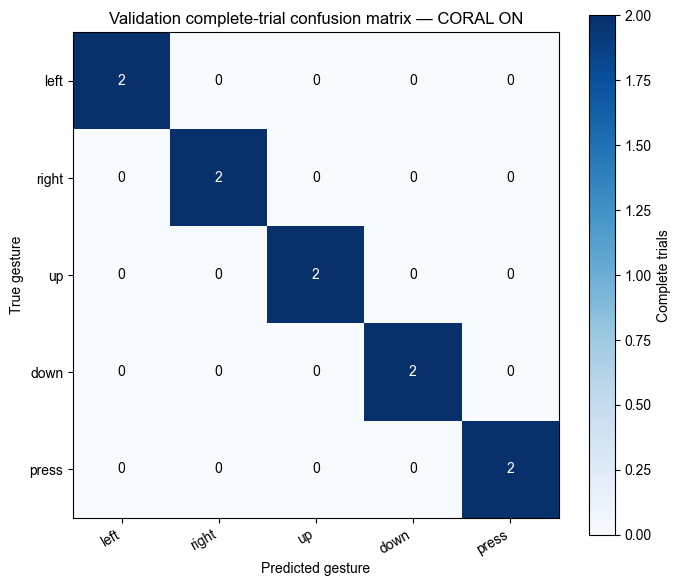

Saved Adobe-compatible figure: test_confusion_matrix
  C:\Users\Micah\utah-neuro\MATLAB_Jupyter\03_online_domain_adaptation\meta_coral_experiment\training_figures\test_confusion_matrix.svg
  C:\Users\Micah\utah-neuro\MATLAB_Jupyter\03_online_domain_adaptation\meta_coral_experiment\training_figures\test_confusion_matrix.pdf
  C:\Users\Micah\utah-neuro\MATLAB_Jupyter\03_online_domain_adaptation\meta_coral_experiment\training_figures\test_confusion_matrix.png


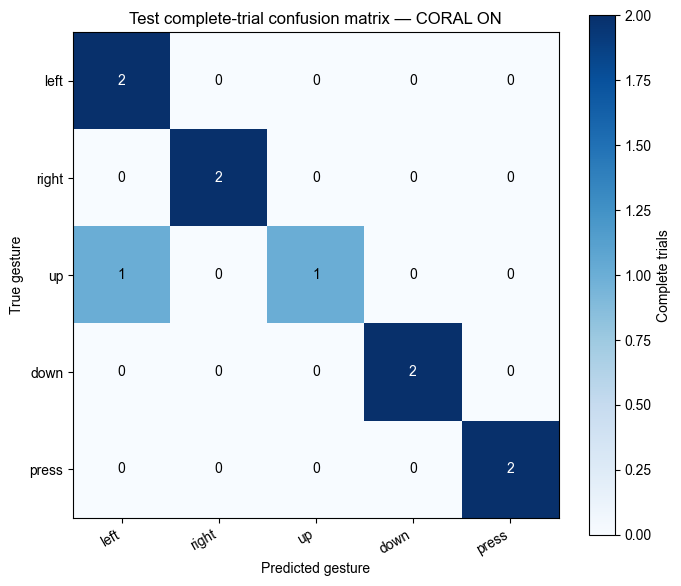

Saved Adobe-compatible figure: training_validation_loss
  C:\Users\Micah\utah-neuro\MATLAB_Jupyter\03_online_domain_adaptation\meta_coral_experiment\training_figures\training_validation_loss.svg
  C:\Users\Micah\utah-neuro\MATLAB_Jupyter\03_online_domain_adaptation\meta_coral_experiment\training_figures\training_validation_loss.pdf
  C:\Users\Micah\utah-neuro\MATLAB_Jupyter\03_online_domain_adaptation\meta_coral_experiment\training_figures\training_validation_loss.png


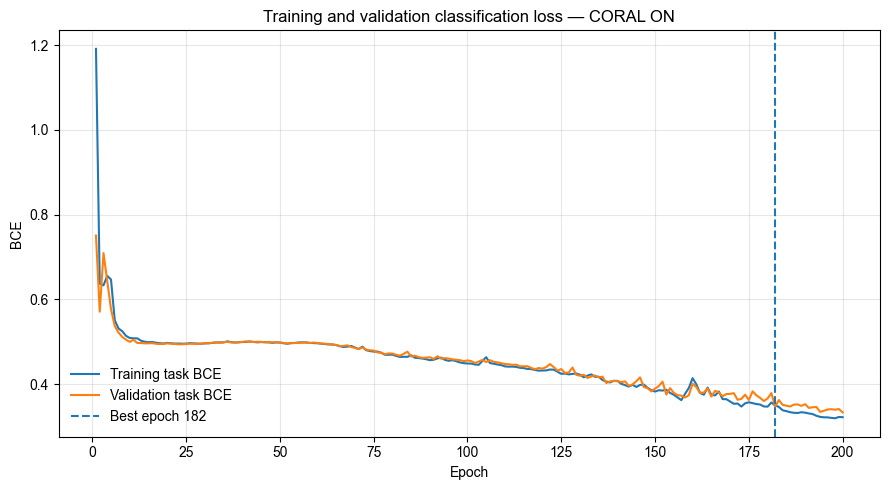

Saved Adobe-compatible figure: training_validation_accuracy
  C:\Users\Micah\utah-neuro\MATLAB_Jupyter\03_online_domain_adaptation\meta_coral_experiment\training_figures\training_validation_accuracy.svg
  C:\Users\Micah\utah-neuro\MATLAB_Jupyter\03_online_domain_adaptation\meta_coral_experiment\training_figures\training_validation_accuracy.pdf
  C:\Users\Micah\utah-neuro\MATLAB_Jupyter\03_online_domain_adaptation\meta_coral_experiment\training_figures\training_validation_accuracy.png


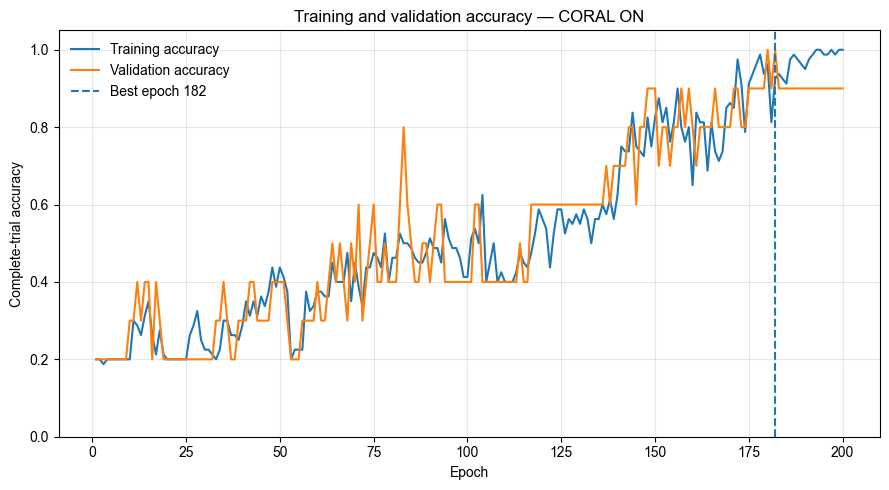

Saved Adobe-compatible figure: validation_test_accuracy_summary
  C:\Users\Micah\utah-neuro\MATLAB_Jupyter\03_online_domain_adaptation\meta_coral_experiment\training_figures\validation_test_accuracy_summary.svg
  C:\Users\Micah\utah-neuro\MATLAB_Jupyter\03_online_domain_adaptation\meta_coral_experiment\training_figures\validation_test_accuracy_summary.pdf
  C:\Users\Micah\utah-neuro\MATLAB_Jupyter\03_online_domain_adaptation\meta_coral_experiment\training_figures\validation_test_accuracy_summary.png


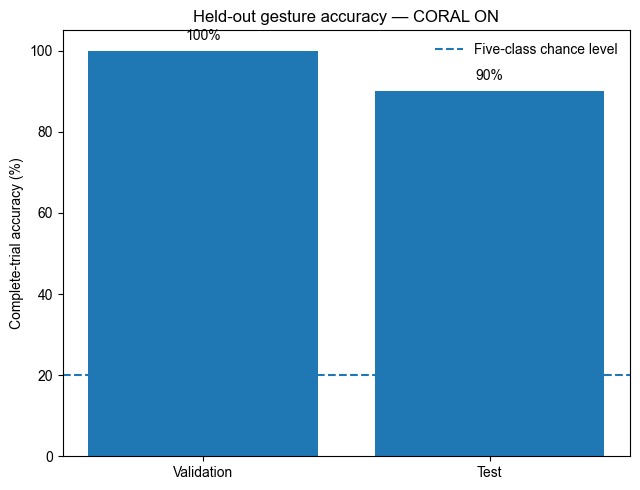


Completed run with CORAL DA ON. Change USE_CORAL_DA in Cell 1 and rerun Cells 1–6 to perform the matched comparison.

All poster files were exported to:
C:\Users\Micah\utah-neuro\MATLAB_Jupyter\03_online_domain_adaptation\meta_coral_experiment\training_figures
Vector formats: SVG and PDF
Raster fallback: 300-dpi PNG
Numerical data: CSV


In [12]:
# ============================================================
# CELL 6 — TRAIN ADAPTER ONLY + SELECT BEST VALIDATION EPOCH
# Test is evaluated once, after restoring the best adapter state.
# ============================================================

import copy
import csv
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt


# Preserve editable text in SVG and TrueType text in PDF for Adobe.
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = [
    "Arial",
    "Helvetica",
    "DejaVu Sans",
]


def save_figure_adobe(
    figure,
    output_dir,
    stem,
):
    """
    Save one figure as editable SVG, vector PDF, and 300-dpi PNG.
    """
    output_dir = Path(output_dir)

    output_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    saved_paths = []

    for extension, extra_kwargs in (
        ("svg", {}),
        ("pdf", {}),
        ("png", {"dpi": 300}),
    ):
        path = output_dir / f"{stem}.{extension}"

        figure.savefig(
            path,
            bbox_inches="tight",
            pad_inches=0.05,
            facecolor="white",
            **extra_kwargs,
        )

        saved_paths.append(path)

    print(f"Saved Adobe-compatible figure: {stem}")
    for path in saved_paths:
        print(" ", path.resolve())


if "PREFLIGHT_PASSED" not in globals():
    raise RuntimeError("Run Cell 5 before training.")

if not PREFLIGHT_PASSED:
    raise RuntimeError(
        "Preflight structural checks failed. Fix Cell 5 errors first."
    )

if (
    USE_CORAL_DA
    and unsafe_coral_ratio
    and not ALLOW_UNSAFE_CORAL_START
):
    raise RuntimeError(
        "Weighted CORAL is catastrophically larger than task loss. "
        "Use the Cell 5 diagnostic before training."
    )


def reset_adapter():
    model.adapter.load_state_dict(
        copy.deepcopy(initial_adapter_state)
    )
    model.to(DEVICE)


def build_adamw_parameter_groups(module, weight_decay):
    decay = []
    no_decay = []

    for name, parameter in module.named_parameters():
        if not parameter.requires_grad:
            continue

        name_lower = name.lower()

        if (
            parameter.ndim <= 1
            or name_lower.endswith(".bias")
            or "norm" in name_lower
            or "residual_scale" in name_lower
            or "output_gain" in name_lower
        ):
            no_decay.append(parameter)
        else:
            decay.append(parameter)

    if not decay and not no_decay:
        raise RuntimeError("No trainable adapter parameters found.")

    groups = []

    if decay:
        groups.append({
            "params": decay,
            "weight_decay": float(weight_decay),
        })

    if no_decay:
        groups.append({
            "params": no_decay,
            "weight_decay": 0.0,
        })

    return groups


def build_optimizer(lr=AO_LR):
    parameter_groups = build_adamw_parameter_groups(
        model.adapter,
        AO_WEIGHT_DECAY,
    )

    return torch.optim.AdamW(
        parameter_groups,
        lr=float(lr),
    )


def scheduled_lr(epoch_number):
    if epoch_number <= AO_WARMUP_EPOCHS:
        fraction = epoch_number / max(1, AO_WARMUP_EPOCHS)
        return AO_LR * fraction

    if epoch_number >= AO_DECAY_EPOCH:
        return AO_LR * AO_DECAY_FACTOR

    return AO_LR


def set_optimizer_lr(optimizer, lr):
    for parameter_group in optimizer.param_groups:
        parameter_group["lr"] = float(lr)


def set_model_mode(train):
    model.train(train)
    model.meta_model.eval()


def next_source_batch():
    global source_iter

    if not USE_CORAL_DA:
        return None

    try:
        batch = next(source_iter)
    except StopIteration:
        source_iter = iter(source_loader)
        batch = next(source_iter)

    return batch.to(DEVICE).float()


def trial_predictions(logits, target, valid_mask, gestures):
    """
    Return one mean-logit prediction per complete trial.

    The mapped Meta outputs are trained with independent BCE, but the Utah
    task requires one gesture decision per trial. Therefore, logits are
    averaged across active-valid output bins and the largest mean logit is
    selected.
    """
    active = target.max(dim=1).values > 0.5
    valid = valid_mask > 0.5
    keep = active & valid

    results = []

    for batch_index in range(logits.shape[0]):
        trial_keep = keep[batch_index]

        if int(trial_keep.sum().item()) == 0:
            raise RuntimeError(
                f"Batch item {batch_index} has no active valid output bins."
            )

        true_class = int(gestures[batch_index].item())

        if not 0 <= true_class < AO_KEPT_CLASSES:
            raise ValueError(
                f"Invalid trial gesture id {true_class}."
            )

        mean_logits = logits[
            batch_index,
            :,
            trial_keep,
        ].mean(dim=1)

        prediction = int(mean_logits.argmax().item())

        # Softmax is used only to display normalized mutually exclusive scores.
        # Training remains independent-output BCEWithLogits.
        normalized_scores = torch.softmax(
            mean_logits,
            dim=0,
        ).detach().cpu()

        results.append({
            "batch_index": batch_index,
            "true": true_class,
            "prediction": prediction,
            "normalized_scores": normalized_scores,
            "active_bins": int(trial_keep.sum().item()),
        })

    return results


def run_epoch(loader, train):
    set_model_mode(train)

    total_loss_sum = 0.0
    task_loss_sum = 0.0
    coral_loss_sum = 0.0
    batch_count = 0

    correct_trials = 0
    trial_total = 0
    wrong_trials = []

    raw_output_min = float("inf")
    raw_output_max = float("-inf")

    for batch in loader:
        emg, target, valid_mask, gestures, trial_nums = ao_unpack_batch(batch)

        if train:
            ao_optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train):
            raw_meta_output, adapter_output = model.forward_with_adapter(emg)

            raw_output_min = min(
                raw_output_min,
                float(raw_meta_output.detach().min().item()),
            )
            raw_output_max = max(
                raw_output_max,
                float(raw_meta_output.detach().max().item()),
            )

            logits = map_meta_outputs_to_utah(raw_meta_output)

            target, valid_mask = align_target_and_mask_to_logits(
                target,
                valid_mask,
                logits.shape[-1],
            )

            task_loss = active_only_multilabel_bce(
                logits,
                target,
                valid_mask,
            )

            coral_loss = torch.zeros(
                (),
                device=DEVICE,
            )

            if train and USE_CORAL_DA:
                source_emg = next_source_batch()

                coral_loss = emg_feature_coral_loss(
                    source_emg,
                    adapter_output,
                )

            weighted_coral = (
                EMG_FEATURE_CORAL_LAMBDA * coral_loss
            )

            total_loss = task_loss + weighted_coral

            if not torch.isfinite(total_loss):
                raise FloatingPointError(
                    "Non-finite total loss detected."
                )

            if train:
                total_loss.backward()

                gradient_norm = torch.nn.utils.clip_grad_norm_(
                    [
                        parameter
                        for parameter in model.adapter.parameters()
                        if parameter.requires_grad
                    ],
                    max_norm=AO_GRAD_CLIP_NORM,
                )

                if not torch.isfinite(gradient_norm):
                    raise FloatingPointError(
                        "Non-finite adapter gradient norm detected."
                    )

                ao_optimizer.step()

        batch_results = trial_predictions(
            logits.detach(),
            target.detach(),
            valid_mask.detach(),
            gestures.detach(),
        )

        for result in batch_results:
            is_correct = (
                result["prediction"] == result["true"]
            )

            correct_trials += int(is_correct)
            trial_total += 1

            if not is_correct:
                batch_index = result["batch_index"]

                wrong_trials.append({
                    "trial_num": int(
                        trial_nums[batch_index].item()
                    ),
                    "true": int(result["true"]),
                    "prediction": int(
                        result["prediction"]
                    ),
                })

        total_loss_sum += float(total_loss.detach().item())
        task_loss_sum += float(task_loss.detach().item())
        coral_loss_sum += float(coral_loss.detach().item())
        batch_count += 1

    denominator = max(1, batch_count)

    return {
        "total_loss": total_loss_sum / denominator,
        "task_loss": task_loss_sum / denominator,
        "coral_loss": coral_loss_sum / denominator,
        "accuracy": correct_trials / max(1, trial_total),
        "num_trials": trial_total,
        "wrong_trials": wrong_trials,
        "raw_output_min": raw_output_min,
        "raw_output_max": raw_output_max,
    }


def detailed_trial_evaluation(loader, split_name):
    set_model_mode(False)

    confusion = torch.zeros(
        AO_KEPT_CLASSES,
        AO_KEPT_CLASSES,
        dtype=torch.long,
    )

    rows = []

    with torch.no_grad():
        for batch in loader:
            emg, target, valid_mask, gestures, trial_nums = ao_unpack_batch(batch)

            raw_meta_output = model(emg)
            logits = map_meta_outputs_to_utah(raw_meta_output)

            target, valid_mask = align_target_and_mask_to_logits(
                target,
                valid_mask,
                logits.shape[-1],
            )

            batch_results = trial_predictions(
                logits,
                target,
                valid_mask,
                gestures,
            )

            for result in batch_results:
                batch_index = result["batch_index"]
                true_class = result["true"]
                predicted_class = result["prediction"]

                confusion[true_class, predicted_class] += 1

                rows.append({
                    "trial_num": int(
                        trial_nums[batch_index].item()
                    ),
                    "true": true_class,
                    "predicted": predicted_class,
                    "normalized_scores": (
                        result["normalized_scores"].numpy()
                    ),
                    "active_bins": result["active_bins"],
                })

    correct = int(confusion.diag().sum().item())
    total = int(confusion.sum().item())
    accuracy = correct / max(1, total)

    print()
    print("=" * 80)
    print(f"{split_name.upper()} COMPLETE-TRIAL RESULTS")
    print("=" * 80)
    print(f"Accuracy: {correct}/{total} = {accuracy:.4f}")

    for row in rows:
        score_text = ", ".join(
            f"{AO_CLASS_NAMES[index]}="
            f"{row['normalized_scores'][index]:.3f}"
            for index in range(AO_KEPT_CLASSES)
        )

        print(
            f"trial {row['trial_num']:>3} | "
            f"true={AO_CLASS_NAMES[row['true']]} | "
            f"pred={AO_CLASS_NAMES[row['predicted']]} | "
            f"active bins={row['active_bins']} | "
            f"{score_text}"
        )

    return confusion, rows, accuracy


def plot_confusion(
    confusion,
    title,
    output_dir,
    export_stem,
):
    matrix = confusion.numpy()

    figure, axis = plt.subplots(
        figsize=(7, 6)
    )

    image = axis.imshow(
        matrix,
        interpolation="nearest",
        cmap="Blues",
    )

    figure.colorbar(
        image,
        ax=axis,
        label="Complete trials",
    )

    axis.set_title(title)
    axis.set_xlabel("Predicted gesture")
    axis.set_ylabel("True gesture")

    ticks = np.arange(AO_KEPT_CLASSES)
    short_names = [
        "left",
        "right",
        "up",
        "down",
        "press",
    ]

    axis.set_xticks(
        ticks,
        short_names,
        rotation=30,
        ha="right",
    )

    axis.set_yticks(
        ticks,
        short_names,
    )

    threshold = (
        matrix.max() / 2.0
        if matrix.size
        else 0.0
    )

    for row in range(
        matrix.shape[0]
    ):
        for column in range(
            matrix.shape[1]
        ):
            axis.text(
                column,
                row,
                str(matrix[row, column]),
                ha="center",
                va="center",
                color=(
                    "white"
                    if matrix[row, column] > threshold
                    else "black"
                ),
            )

    figure.tight_layout()

    save_figure_adobe(
        figure,
        output_dir,
        export_stem,
    )

    plt.show()

    return figure


reset_adapter()
ao_optimizer = build_optimizer(AO_LR)

history = {
    "train_task_loss": [],
    "val_task_loss": [],
    "train_total_loss": [],
    "train_coral_loss": [],
    "train_accuracy": [],
    "val_accuracy": [],
}

best_adapter_state = None
best_epoch = None
best_val_accuracy = float("-inf")
best_val_task_loss = float("inf")

coral_mode_text = "ON" if USE_CORAL_DA else "OFF"

RESULTS_EXPORT_DIR = DA_EXPERIMENT_DIR / "training_figures"

RESULTS_EXPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("Figure export directory:")
print(RESULTS_EXPORT_DIR.resolve())
print()

print("Starting corrected fixed-split training.")
print("  Train trials:", len(train_loader.dataset))
print("  Validation trials:", len(val_loader.dataset))
print("  Test trials held blind:", len(test_loader.dataset))
print("  Mapped Meta outputs:", UTAH_TO_META_OUTPUTS)
print("  Meta backbone frozen:", True)
print("  CORAL DA:", coral_mode_text)

for epoch in range(1, AO_EPOCHS + 1):
    current_lr = scheduled_lr(epoch)
    set_optimizer_lr(ao_optimizer, current_lr)

    train_metrics = run_epoch(train_loader, train=True)
    val_metrics = run_epoch(val_loader, train=False)

    history["train_task_loss"].append(train_metrics["task_loss"])
    history["val_task_loss"].append(val_metrics["task_loss"])
    history["train_total_loss"].append(train_metrics["total_loss"])
    history["train_coral_loss"].append(train_metrics["coral_loss"])
    history["train_accuracy"].append(train_metrics["accuracy"])
    history["val_accuracy"].append(val_metrics["accuracy"])

    weighted_coral_epoch = (
        EMG_FEATURE_CORAL_LAMBDA
        * train_metrics["coral_loss"]
    )

    epoch_line = (
        f"Epoch {epoch:03d}/{AO_EPOCHS} | "
        f"lr {current_lr:.2e} | "
        f"train BCE {train_metrics['task_loss']:.4f} | "
        f"val BCE {val_metrics['task_loss']:.4f} | "
        f"train acc {train_metrics['accuracy']:.3f} | "
        f"val acc {val_metrics['accuracy']:.3f}"
    )

    if USE_CORAL_DA:
        epoch_line += (
            f" | CORAL {train_metrics['coral_loss']:.4f} | "
            f"weighted CORAL {weighted_coral_epoch:.4f}"
        )
    else:
        epoch_line += " | CORAL OFF"

    # With five validation trials, 0.8 means exactly one trial is wrong.
    # Report only that error so repeated 0.8 epochs reveal whether the
    # same validation gesture is systematically misclassified.
    if np.isclose(val_metrics["accuracy"], 0.8):
        wrong_val_trials = val_metrics["wrong_trials"]

        if len(wrong_val_trials) == 1:
            wrong = wrong_val_trials[0]

            epoch_line += (
                " | wrong val: "
                f"G{wrong['true']} trial {wrong['trial_num']} "
                f"({AO_CLASS_NAMES[wrong['true']]} -> "
                f"{AO_CLASS_NAMES[wrong['prediction']]})"
            )
        else:
            epoch_line += (
                " | wrong val count mismatch: "
                f"{len(wrong_val_trials)}"
            )

    print(epoch_line)

    val_accuracy = val_metrics["accuracy"]
    val_loss = val_metrics["task_loss"]

    is_better = (
        val_accuracy > best_val_accuracy
        or (
            np.isclose(val_accuracy, best_val_accuracy)
            and val_loss < best_val_task_loss
        )
    )

    if is_better:
        best_val_accuracy = val_accuracy
        best_val_task_loss = val_loss
        best_epoch = epoch
        best_adapter_state = copy.deepcopy(
            model.adapter.state_dict()
        )

if best_adapter_state is None:
    raise RuntimeError("No best adapter state was recorded.")

model.adapter.load_state_dict(best_adapter_state)
model.to(DEVICE)
model.meta_model.eval()

print()
print(
    f"Restored best adapter from epoch {best_epoch}: "
    f"val accuracy={best_val_accuracy:.4f}, "
    f"val task BCE={best_val_task_loss:.4f}"
)

# Verify that training did not mutate the frozen Meta backbone.
final_meta_signature = module_numeric_signature(model.meta_model)

if final_meta_signature != initial_meta_signature:
    raise RuntimeError(
        "Frozen Meta backbone changed during adapter training."
    )

test_metrics = run_epoch(test_loader, train=False)

print()
print("=" * 80)
print("FINAL BLIND TEST — BEST VALIDATION-SELECTED ADAPTER")
print("=" * 80)
print("CORAL DA:", coral_mode_text)
print("Best epoch:", best_epoch)
print("Test task BCE:", round(test_metrics["task_loss"], 4))
print("Test accuracy:", round(test_metrics["accuracy"], 4))

val_confusion, val_rows, val_accuracy = detailed_trial_evaluation(
    val_loader,
    "Validation",
)
test_confusion, test_rows, test_accuracy = detailed_trial_evaluation(
    test_loader,
    "Test",
)

plot_confusion(
    val_confusion,
    (
        "Validation complete-trial confusion matrix "
        f"— CORAL {coral_mode_text}"
    ),
    output_dir=RESULTS_EXPORT_DIR,
    export_stem="validation_confusion_matrix",
)

plot_confusion(
    test_confusion,
    (
        "Test complete-trial confusion matrix "
        f"— CORAL {coral_mode_text}"
    ),
    output_dir=RESULTS_EXPORT_DIR,
    export_stem="test_confusion_matrix",
)

epochs = np.arange(
    1,
    AO_EPOCHS + 1,
)


# ------------------------------------------------------------
# Training and validation task loss
# ------------------------------------------------------------

loss_figure, loss_axis = plt.subplots(
    figsize=(9, 5)
)

loss_axis.plot(
    epochs,
    history["train_task_loss"],
    label="Training task BCE",
)

loss_axis.plot(
    epochs,
    history["val_task_loss"],
    label="Validation task BCE",
)

loss_axis.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch {best_epoch}",
)

loss_axis.set(
    xlabel="Epoch",
    ylabel="BCE",
    title=(
        "Training and validation classification loss "
        f"— CORAL {coral_mode_text}"
    ),
)

loss_axis.grid(
    True,
    alpha=0.3,
)

loss_axis.legend(
    frameon=False,
)

loss_figure.tight_layout()

save_figure_adobe(
    loss_figure,
    RESULTS_EXPORT_DIR,
    "training_validation_loss",
)

plt.show()


# ------------------------------------------------------------
# Training and validation complete-trial accuracy
# ------------------------------------------------------------

accuracy_figure, accuracy_axis = plt.subplots(
    figsize=(9, 5)
)

accuracy_axis.plot(
    epochs,
    history["train_accuracy"],
    label="Training accuracy",
)

accuracy_axis.plot(
    epochs,
    history["val_accuracy"],
    label="Validation accuracy",
)

accuracy_axis.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch {best_epoch}",
)

accuracy_axis.set(
    xlabel="Epoch",
    ylabel="Complete-trial accuracy",
    ylim=(0, 1.05),
    title=(
        "Training and validation accuracy "
        f"— CORAL {coral_mode_text}"
    ),
)

accuracy_axis.grid(
    True,
    alpha=0.3,
)

accuracy_axis.legend(
    frameon=False,
)

accuracy_figure.tight_layout()

save_figure_adobe(
    accuracy_figure,
    RESULTS_EXPORT_DIR,
    "training_validation_accuracy",
)

plt.show()


# ------------------------------------------------------------
# Poster-ready validation/test summary
# ------------------------------------------------------------

summary_labels = [
    "Validation",
    "Test",
]

summary_values = [
    100.0 * val_accuracy,
    100.0 * test_accuracy,
]

summary_figure, summary_axis = plt.subplots(
    figsize=(6.5, 5)
)

summary_bars = summary_axis.bar(
    summary_labels,
    summary_values,
)

summary_axis.axhline(
    20.0,
    linestyle="--",
    linewidth=1.5,
    label="Five-class chance level",
)

summary_axis.set(
    ylabel="Complete-trial accuracy (%)",
    ylim=(0, 105),
    title=(
        "Held-out gesture accuracy "
        f"— CORAL {coral_mode_text}"
    ),
)

summary_axis.legend(
    frameon=False,
)

for bar, value in zip(
    summary_bars,
    summary_values,
):
    summary_axis.text(
        bar.get_x() + bar.get_width() / 2,
        value + 2,
        f"{value:.0f}%",
        ha="center",
        va="bottom",
    )

summary_figure.tight_layout()

save_figure_adobe(
    summary_figure,
    RESULTS_EXPORT_DIR,
    "validation_test_accuracy_summary",
)

plt.show()


# ------------------------------------------------------------
# Export numerical values alongside the figures
# ------------------------------------------------------------

history_csv_path = (
    RESULTS_EXPORT_DIR
    / "training_history.csv"
)

with history_csv_path.open(
    "w",
    newline="",
    encoding="utf-8",
) as handle:
    writer = csv.writer(handle)

    writer.writerow([
        "epoch",
        "train_task_bce",
        "validation_task_bce",
        "train_total_loss",
        "train_coral_loss",
        "train_accuracy",
        "validation_accuracy",
    ])

    for epoch_index in range(
        AO_EPOCHS
    ):
        writer.writerow([
            epoch_index + 1,
            history["train_task_loss"][epoch_index],
            history["val_task_loss"][epoch_index],
            history["train_total_loss"][epoch_index],
            history["train_coral_loss"][epoch_index],
            history["train_accuracy"][epoch_index],
            history["val_accuracy"][epoch_index],
        ])


summary_csv_path = (
    RESULTS_EXPORT_DIR
    / "run_summary.csv"
)

with summary_csv_path.open(
    "w",
    newline="",
    encoding="utf-8",
) as handle:
    writer = csv.writer(handle)

    writer.writerow([
        "coral_enabled",
        "best_epoch",
        "best_validation_accuracy",
        "best_validation_task_bce",
        "final_validation_accuracy",
        "test_accuracy",
        "test_task_bce",
    ])

    writer.writerow([
        bool(USE_CORAL_DA),
        best_epoch,
        best_val_accuracy,
        best_val_task_loss,
        val_accuracy,
        test_accuracy,
        test_metrics["task_loss"],
    ])


def save_confusion_csv(
    matrix,
    filename,
):
    matrix = matrix.numpy()

    path = (
        RESULTS_EXPORT_DIR
        / filename
    )

    short_names = [
        "left",
        "right",
        "up",
        "down",
        "press",
    ]

    with path.open(
        "w",
        newline="",
        encoding="utf-8",
    ) as handle:
        writer = csv.writer(handle)

        writer.writerow([
            "true\\predicted",
            *short_names,
        ])

        for label, row in zip(
            short_names,
            matrix,
        ):
            writer.writerow([
                label,
                *row.tolist(),
            ])


save_confusion_csv(
    val_confusion,
    "validation_confusion_matrix.csv",
)

save_confusion_csv(
    test_confusion,
    "test_confusion_matrix.csv",
)

print()
print(
    f"Completed run with CORAL DA {coral_mode_text}. "
    "Change USE_CORAL_DA in Cell 1 and rerun Cells 1–6 "
    "to perform the matched comparison."
)

print()
print("All poster files were exported to:")
print(RESULTS_EXPORT_DIR.resolve())
print("Vector formats: SVG and PDF")
print("Raster fallback: 300-dpi PNG")
print("Numerical data: CSV")


## Save the validation-selected Meta-CORAL checkpoint

Run this after the training cell finishes and restores `best_adapter_state`. It freezes the entire composite model and saves a checksum-verified checkpoint for the online evaluator.


In [13]:
import hashlib


def full_model_sha256(module):
    digest = hashlib.sha256()
    for name, tensor in sorted(module.state_dict().items()):
        value = tensor.detach().cpu().contiguous()
        digest.update(name.encode("utf-8"))
        digest.update(str(value.dtype).encode("ascii"))
        digest.update(np.asarray(value.shape, dtype=np.int64).tobytes())
        digest.update(value.numpy().tobytes())
    return digest.hexdigest()


if best_adapter_state is None:
    raise RuntimeError("Training did not record a validation-selected adapter.")

# Restore explicitly, then freeze both adapter and Meta backbone.
model.adapter.load_state_dict(copy.deepcopy(best_adapter_state))
model.to(DEVICE).eval()
for parameter in model.parameters():
    parameter.requires_grad_(False)

if any(parameter.requires_grad for parameter in model.parameters()):
    raise RuntimeError("At least one parameter remains trainable.")

DA_CHECKPOINT_PATH = DA_EXPERIMENT_DIR / "best_meta_source_coral_adapter.pt"
model_digest = full_model_sha256(model)

torch.save(
    {
        "format_version": 1,
        "training_dataset": str(DATA_PATH),
        "coral_source_directory": str(META_SOURCE_DIR),
        "coral_enabled": bool(USE_CORAL_DA),
        "coral_lambda": float(EMG_FEATURE_CORAL_LAMBDA),
        "best_epoch": int(best_epoch),
        "best_validation_accuracy": float(best_val_accuracy),
        "best_validation_task_bce": float(best_val_task_loss),
        "utah_to_meta_outputs": list(UTAH_TO_META_OUTPUTS),
        "model_state_dict": {
            key: value.detach().cpu().clone()
            for key, value in model.state_dict().items()
        },
        "model_sha256": model_digest,
    },
    DA_CHECKPOINT_PATH,
)

print("Saved frozen Meta-source CORAL checkpoint:")
print(DA_CHECKPOINT_PATH.resolve())
print("SHA-256:", model_digest)
print("Best epoch:", best_epoch)
print("Best validation accuracy:", best_val_accuracy)


Saved frozen Meta-source CORAL checkpoint:
C:\Users\Micah\utah-neuro\MATLAB_Jupyter\03_online_domain_adaptation\meta_coral_experiment\best_meta_source_coral_adapter.pt
SHA-256: 651cb3f81f2a2a6b14d268ec064cd761d4939e2feef03fa3d7d3977df3afa44d
Best epoch: 182
Best validation accuracy: 1.0


## Full label-blind evaluation on the 53-trial prior dataset

This cell runs the same verified blind detector and classifier pipeline with the new CORAL checkpoint. It reconstructs the 53 saved trials as a continuous stream. Only after predictions are fixed does it use final auto-relabeled `trainKin` for scoring.


In [14]:
import runpy
import sys


ONLINE_EVALUATOR_PATH = Path(
    r"C:\Users\Micah\utah-neuro\MATLAB_Jupyter\03_online_domain_adaptation\full_pipeline\full_label_blind_online_evaluation.py"
)
ONLINE_53_DATASET_PATH = (
    REPO_ROOT / "Gesture_Trial_Dataset_Labeled.pt"
)
ONLINE_53_RESULTS_DIR = (
    DA_EXPERIMENT_DIR / "online_53_trial_results"
)

for required_path in (
    ONLINE_EVALUATOR_PATH,
    ONLINE_53_DATASET_PATH,
    DA_CHECKPOINT_PATH,
):
    if not required_path.exists():
        raise FileNotFoundError(required_path)

saved_argv = sys.argv[:]
try:
    sys.argv = [
        str(ONLINE_EVALUATOR_PATH),
        str(ONLINE_53_DATASET_PATH),
        str(DA_CHECKPOINT_PATH),
        str(ONLINE_53_RESULTS_DIR),
    ]
    runpy.run_path(
        str(ONLINE_EVALUATOR_PATH),
        run_name="__main__",
    )
finally:
    sys.argv = saved_argv

print()
print("Completed 53-trial full label-blind evaluation.")
print("Results:", ONLINE_53_RESULTS_DIR.resolve())


Loading prior-session continuous trials: C:\Users\Micah\utah-neuro\generic_neuromotor_interface\Gesture_Trial_Dataset_Labeled.pt
Running label-blind burst detection...
Blind events: 56
Loading and freezing selected model...
All predictions finalized; frozen-state verification passed.
{
  "protocol": "EMG-only detection, window centering, active-bin selection, and frozen classification; labels used afterward for scoring only",
  "dataset": "C:\\Users\\Micah\\utah-neuro\\generic_neuromotor_interface\\Gesture_Trial_Dataset_Labeled.pt",
  "checkpoint": "C:\\Users\\Micah\\utah-neuro\\MATLAB_Jupyter\\online_evaluation\\meta_coral_experiment\\best_meta_source_coral_adapter.pt",
  "checkpoint_epoch": 182,
  "model_sha256": "651cb3f81f2a2a6b14d268ec064cd761d4939e2feef03fa3d7d3977df3afa44d",
  "duration_seconds": 139.98213333333334,
  "predicted_events": 56,
  "truth_events": 48,
  "matched_events": 47,
  "missed_events": 1,
  "false_detections": 9,
  "detection_precision": 0.8392857142857143,
 